# 3D-CNN Exercise Recognition Training

This notebook implements a 3D Convolutional Neural Network for recognizing exercises from skeleton pose data and training loop. The best model is saved to `output/` directory.

In [9]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 1. Configuration

In [11]:
# Paths
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
SKELETON_DIR = DATA_DIR / "dataset" / "skeleton" / "yolo_pose_csv"
LABEL_DIR = DATA_DIR / "label"
SPLIT_FILE = DATA_DIR / "split.csv"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

In [12]:
# Model hyperparameters
CONFIG = {
    # Data parameters
    'sequence_length': 64,      # Number of frames per sample (temporal dimension)
    'stride': 32,               # Stride for sliding window
    'num_keypoints': 17,        # YOLO pose keypoints
    'num_coords': 3,            # x, y, z coordinates

    # Training parameters
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 50,
    'patience': 10,             # Early stopping patience

    # Model parameters
    'hidden_channels': [32, 64, 128],
    'dropout': 0.3,

    # Data split
    'test_size': 0.2,
    'val_size': 0.1,
}

## 2. Data Loading Functions

In [13]:
def load_skeleton_file(filepath):
    """Load skeleton CSV file and convert to numpy array.
    Returns array of shape (num_frames, num_keypoints, 3)
    """
    df = pd.read_csv(filepath)

    # Get landmark order from first frame
    landmarks_order = df[df['frame_number'] == df['frame_number'].min()]['landmark'].tolist()
    num_keypoints = len(landmarks_order)

    # Get unique frames
    frames = sorted(df['frame_number'].unique())
    num_frames = len(frames)

    # Create array
    skeleton_array = np.zeros((num_frames, num_keypoints, 3), dtype=np.float32)

    for frame_idx, frame_num in enumerate(frames):
        frame_data = df[df['frame_number'] == frame_num]
        for kp_idx, landmark in enumerate(landmarks_order):
            kp_data = frame_data[frame_data['landmark'] == landmark]
            if len(kp_data) > 0:
                skeleton_array[frame_idx, kp_idx, 0] = kp_data['x'].values[0]
                skeleton_array[frame_idx, kp_idx, 1] = kp_data['y'].values[0]
                skeleton_array[frame_idx, kp_idx, 2] = kp_data['z'].values[0]

    return skeleton_array, landmarks_order


def load_label_file(filepath):
    """Load label CSV file.
    Returns array of labels for each frame.
    """
    df = pd.read_csv(filepath, header=None, names=['frame', 'col1', 'label'])
    return df['label'].values


def get_matching_files(skeleton_dir, label_dir):
    """Get list of files that exist in both skeleton and label directories."""
    skeleton_files = set([f.replace('.csv', '') for f in os.listdir(skeleton_dir) if f.endswith('.csv')])
    label_files = set([f.replace('.csv', '') for f in os.listdir(label_dir) if f.endswith('.csv')])
    return sorted(list(skeleton_files.intersection(label_files)))

In [14]:
def create_sequences(skeleton_data, labels, sequence_length, stride, exclude_no_activity=True):
    """Create sequences from skeleton data using sliding window.
    
    Args:
        skeleton_data: Array of shape (num_frames, num_keypoints, 3)
        labels: Array of labels for each frame
        sequence_length: Number of frames per sequence
        stride: Step size for sliding window
        exclude_no_activity: If True, skip sequences with only no-activity labels
    
    Returns:
        sequences: List of arrays, each (sequence_length, num_keypoints, 3)
        sequence_labels: List of labels (majority vote for each sequence)

    """
    sequences = []
    sequence_labels = []

    num_frames = len(skeleton_data)

    for start_idx in range(0, num_frames - sequence_length + 1, stride):
        end_idx = start_idx + sequence_length

        # Get sequence data
        seq_data = skeleton_data[start_idx:end_idx]
        seq_labels = labels[start_idx:end_idx]

        # Get majority label (excluding -1 if there are exercise labels)
        exercise_labels = seq_labels[seq_labels != -1]

        if len(exercise_labels) > 0:
            # Use majority vote among exercise labels
            label_counts = Counter(exercise_labels)
            majority_label = label_counts.most_common(1)[0][0]
        else:
            if exclude_no_activity:
                continue
            majority_label = -1

        sequences.append(seq_data)
        sequence_labels.append(majority_label)

    return sequences, sequence_labels

## 3. Load and Process All Data (using split.csv)

In [15]:
# Load split file
split_df = pd.read_csv(SPLIT_FILE, header=None, names=['file_name', 'split'])
train_files = set(split_df[split_df['split'] == 'train']['file_name'].tolist())
test_files = set(split_df[split_df['split'] == 'test']['file_name'].tolist())

print(f"Split from split.csv:")
print(f"  Train files: {len(train_files)}")
print(f"  Test files: {len(test_files)}")

# Get matching files (exist in skeleton, label AND split)
all_split_files = train_files.union(test_files)
matching_files = get_matching_files(SKELETON_DIR, LABEL_DIR)
matching_files = [f for f in matching_files if f in all_split_files]
print(f"Found {len(matching_files)} matching files (in skeleton, label, and split)")

Split from split.csv:
  Train files: 30
  Test files: 30
Found 59 matching files (in skeleton, label, and split)


In [16]:
# Load all data and create sequences - separately for train and test
train_sequences = []
train_labels = []
test_sequences = []
test_labels = []

print("\nLoading and processing files...")
for file_name in tqdm(matching_files):
    skeleton_path = SKELETON_DIR / f"{file_name}.csv"
    label_path = LABEL_DIR / f"{file_name}.csv"

    try:
        # Load data
        skeleton_data, _ = load_skeleton_file(skeleton_path)
        labels = load_label_file(label_path)

        # Ensure same length
        min_len = min(len(skeleton_data), len(labels))
        skeleton_data = skeleton_data[:min_len]
        labels = labels[:min_len]

        # Create sequences
        sequences, seq_labels = create_sequences(
            skeleton_data, labels,
            CONFIG['sequence_length'],
            CONFIG['stride'],
            exclude_no_activity=True
        )

        # Add to appropriate split based on split.csv
        if file_name in train_files:
            train_sequences.extend(sequences)
            train_labels.extend(seq_labels)
        else:
            test_sequences.extend(sequences)
            test_labels.extend(seq_labels)

    except Exception as e:
        print(f"Error processing {file_name}: {e}")

print(f"\nTrain sequences: {len(train_sequences)}")
print(f"Test sequences: {len(test_sequences)}")
print(f"Total sequences: {len(train_sequences) + len(test_sequences)}")


Loading and processing files...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [46:58<00:00, 47.78s/it]


Train sequences: 7948
Test sequences: 6669
Total sequences: 14617


In [17]:
# Convert to numpy arrays
X_train_all = np.array(train_sequences, dtype=np.float32)
y_train_all = np.array(train_labels, dtype=np.int64)
X_test = np.array(test_sequences, dtype=np.float32)
y_test_orig = np.array(test_labels, dtype=np.int64)

# Combine for label mapping
all_labels_combined = np.concatenate([y_train_all, y_test_orig])

print(f"X_train_all shape: {X_train_all.shape}")
print(f"X_test shape: {X_test.shape}")

# Create label mapping (remap labels to 0, 1, 2, ...)
unique_labels = sorted(set(all_labels_combined))
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train_all_mapped = np.array([label_to_idx[label] for label in y_train_all])
y_test = np.array([label_to_idx[label] for label in y_test_orig])
num_classes = len(unique_labels)

print("\nLabel mapping:")
for label, idx in label_to_idx.items():
    train_count = np.sum(y_train_all == label)
    test_count = np.sum(y_test_orig == label)
    print(f"  {label} -> {idx}: {train_count} train, {test_count} test")
print(f"\nNumber of classes: {num_classes}")

X_train_all shape: (7948, 64, 17, 3)
X_test shape: (6669, 64, 17, 3)

Label mapping:
  1 -> 0: 2295 train, 1987 test
  2 -> 1: 401 train, 331 test
  3 -> 2: 373 train, 327 test
  4 -> 3: 360 train, 311 test
  5 -> 4: 389 train, 343 test
  6 -> 5: 356 train, 295 test
  7 -> 6: 366 train, 331 test
  8 -> 7: 395 train, 345 test
  9 -> 8: 344 train, 309 test
  10 -> 9: 357 train, 299 test
  11 -> 10: 355 train, 289 test
  12 -> 11: 396 train, 298 test
  13 -> 12: 406 train, 324 test
  14 -> 13: 379 train, 287 test
  15 -> 14: 409 train, 311 test
  16 -> 15: 367 train, 282 test

Number of classes: 16


## 4. Data Splitting and Dataset Class

In [18]:
# Split train data into train and validation sets
# (Test set is already defined by split.csv)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all_mapped,
    test_size=CONFIG['val_size'],
    random_state=42,
    stratify=y_train_all_mapped
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)} (from split.csv)")

Training samples: 7153
Validation samples: 795
Test samples: 6669 (from split.csv)


In [19]:
class SkeletonDataset(Dataset):
    """PyTorch Dataset for skeleton sequences."""

    def __init__(self, sequences, labels, augment=False):
        """Args:
        sequences: numpy array of shape (N, T, K, 3) - T=temporal, K=keypoints
        labels: numpy array of shape (N,)
        augment: whether to apply data augmentation
        """
        self.sequences = sequences
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        # Get data
        x = self.sequences[idx].copy()  # (T, K, 3)
        y = self.labels[idx]

        # Data augmentation
        if self.augment:
            x = self._augment(x)

        # Transpose to (C, T, K) where C=3 (coordinates as channels)
        # This is suitable for 3D convolution: (batch, channels, depth, height, width)
        # Here: (batch, 3, T, K) where we treat keypoints as spatial dimension
        x = x.transpose(2, 0, 1)  # (3, T, K)

        return torch.FloatTensor(x), torch.LongTensor([y]).squeeze()

    def _augment(self, x):
        """Apply data augmentation to skeleton sequence."""
        # Random horizontal flip (mirror skeleton)
        if np.random.random() > 0.5:
            x[:, :, 0] = 1 - x[:, :, 0]  # Flip x coordinate
            # Swap left/right keypoints
            # YOLO order: NOSE, L_EYE, R_EYE, L_EAR, R_EAR, L_SHOULDER, R_SHOULDER,
            #             L_ELBOW, R_ELBOW, L_WRIST, R_WRIST, L_HIP, R_HIP,
            #             L_KNEE, R_KNEE, L_ANKLE, R_ANKLE
            swap_pairs = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]
            for i, j in swap_pairs:
                x[:, i, :], x[:, j, :] = x[:, j, :].copy(), x[:, i, :].copy()

        # Random noise
        if np.random.random() > 0.5:
            noise = np.random.normal(0, 0.01, x.shape).astype(np.float32)
            x = x + noise

        # Random scaling
        if np.random.random() > 0.5:
            scale = np.random.uniform(0.9, 1.1)
            x = x * scale

        return x

In [20]:
# Create datasets and dataloaders
train_dataset = SkeletonDataset(X_train, y_train, augment=True)
val_dataset = SkeletonDataset(X_val, y_val, augment=False)
test_dataset = SkeletonDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

# Verify data shape
sample_x, sample_y = next(iter(train_loader))
print(f"Sample batch X shape: {sample_x.shape}")  # Expected: (batch_size, 3, T, K)
print(f"Sample batch y shape: {sample_y.shape}")

Sample batch X shape: torch.Size([32, 3, 64, 17])
Sample batch y shape: torch.Size([32])


## 5. 3D-CNN Model Architecture

In [21]:
class Action3DCNN(nn.Module):
    """3D-CNN for skeleton-based action recognition.

    Input shape: (batch, 3, T, K) where:
        - 3: coordinates (x, y, z) as channels
        - T: temporal dimension (sequence_length)
        - K: keypoints (17)

    We treat this as a 2D problem with 3 channels (like RGB image)
    where the spatial dimensions are (T, K) - temporal x keypoints.
    This avoids issues with 3D pooling making dimensions too small.
    """

    def __init__(self, num_classes, sequence_length=64, num_keypoints=17,
                 hidden_channels=[32, 64, 128], dropout=0.3):
        super().__init__()

        self.num_classes = num_classes
        self.sequence_length = sequence_length
        self.num_keypoints = num_keypoints

        # Use 2D convolutions treating (T, K) as spatial dimensions
        # Input: (batch, 3, T, K) - 3 channels (x, y, z), T=height, K=width

        self.conv_layers = nn.ModuleList()

        in_ch = 3  # x, y, z coordinates as channels
        for out_ch in hidden_channels:
            self.conv_layers.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                    nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                    nn.MaxPool2d(kernel_size=2, stride=2)
                )
            )
            in_ch = out_ch

        # Calculate flattened size after conv layers
        self._calc_flat_size(sequence_length, num_keypoints)

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(self.flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        # For GradCAM - store intermediate features
        self.gradients = None
        self.activations = None

    def _calc_flat_size(self, T, K):
        """Calculate size after all conv layers."""
        h, w = T, K
        for _ in self.conv_layers:
            h = h // 2
            w = max(w // 2, 1)
        self.flat_size = self.conv_layers[-1][0].out_channels * h * w

    def activations_hook(self, grad):
        """Hook for gradients."""
        self.gradients = grad

    def forward(self, x):
        # Input x: (batch, 3, T, K) - already in correct format for Conv2d

        # Apply conv layers
        for i, conv_block in enumerate(self.conv_layers):
            x = conv_block(x)

            # Store activations from last conv layer for GradCAM
            if i == len(self.conv_layers) - 1:
                self.activations = x
                if x.requires_grad:
                    x.register_hook(self.activations_hook)

        # Flatten and classify
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self):
        return self.activations

In [22]:
# Create model
model = Action3DCNN(
    num_classes=num_classes,
    sequence_length=CONFIG['sequence_length'],
    num_keypoints=CONFIG['num_keypoints'],
    hidden_channels=CONFIG['hidden_channels'],
    dropout=CONFIG['dropout']
).to(device)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Test forward pass
with torch.no_grad():
    test_input = sample_x.to(device)
    test_output = model(test_input)
    print("\nTest forward pass:")
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")

Action3DCNN(
  (conv_layers): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=

## 6. Training Functions

In [23]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

## 7. Training Loop

In [24]:
# Calculate class weights for imbalanced data
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.FloatTensor(class_weights).to(device)

print("Class weights:", class_weights)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = Adam(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Class weights: tensor([0.1727, 0.9884, 1.0619, 1.1013, 1.0194, 1.1150, 1.0845, 1.0023, 1.1510,
        1.1115, 1.1150, 1.0023, 0.9775, 1.0463, 0.9696, 1.0812],
       device='cuda:0')


In [25]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_model_state = None
patience_counter = 0

print("Starting training...")
print("=" * 70)

for epoch in range(CONFIG['num_epochs']):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print progress
    print(f"Epoch [{epoch+1}/{CONFIG['num_epochs']}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"  -> New best model. Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= CONFIG['patience']:
        print(f"\nEarly stopping after {epoch+1} epochs")
        break

print("=" * 70)
print(f"Training completed! Best validation accuracy: {best_val_acc:.2f}%")

Starting training...
Epoch [1/50] Train Loss: 2.2669, Train Acc: 25.46% | Val Loss: 1.5448, Val Acc: 54.84%
  -> New best model. Val Acc: 54.84%
Epoch [2/50] Train Loss: 1.2128, Train Acc: 55.33% | Val Loss: 0.7245, Val Acc: 74.09%
  -> New best model. Val Acc: 74.09%
Epoch [3/50] Train Loss: 0.8555, Train Acc: 67.27% | Val Loss: 0.7408, Val Acc: 74.97%
  -> New best model. Val Acc: 74.97%
Epoch [4/50] Train Loss: 0.7167, Train Acc: 72.81% | Val Loss: 0.5160, Val Acc: 82.01%
  -> New best model. Val Acc: 82.01%
Epoch [5/50] Train Loss: 0.6250, Train Acc: 75.28% | Val Loss: 0.5367, Val Acc: 76.98%
Epoch [6/50] Train Loss: 0.5633, Train Acc: 78.64% | Val Loss: 0.4760, Val Acc: 83.40%
  -> New best model. Val Acc: 83.40%
Epoch [7/50] Train Loss: 0.5360, Train Acc: 79.71% | Val Loss: 0.4245, Val Acc: 84.28%
  -> New best model. Val Acc: 84.28%
Epoch [8/50] Train Loss: 0.4830, Train Acc: 81.74% | Val Loss: 0.3882, Val Acc: 86.54%
  -> New best model. Val Acc: 86.54%
Epoch [9/50] Train Loss:

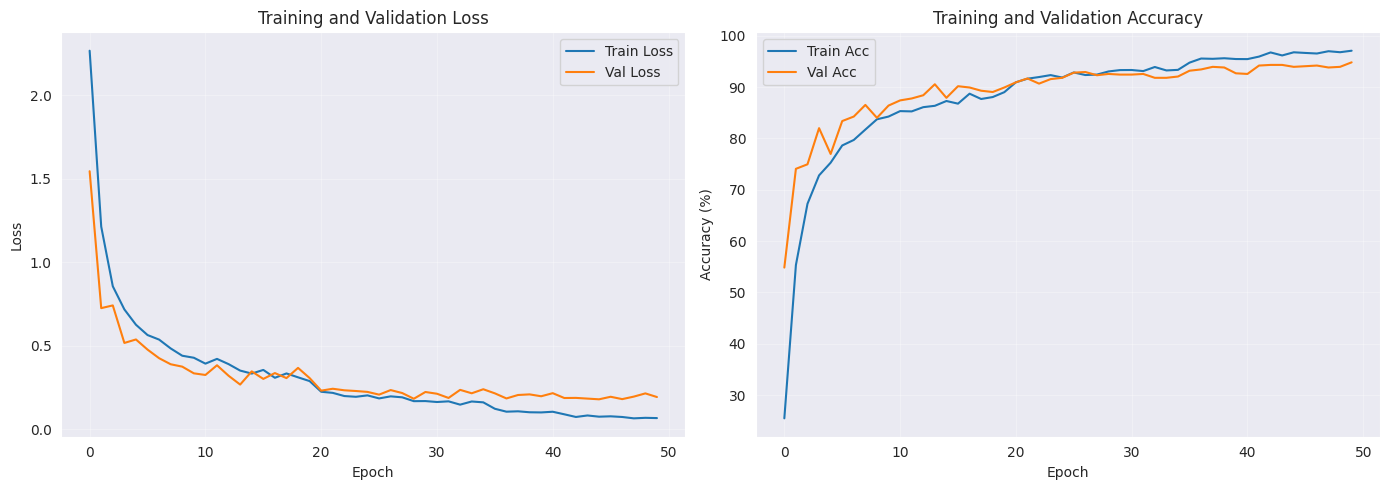

In [26]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150)
plt.show()

## 8. Model Evaluation

In [27]:
# Load best model
model.load_state_dict(best_model_state)

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification report
class_names = [f"Exercise {idx_to_label[i]}" for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

Test Loss: 0.4031
Test Accuracy: 91.74%

Classification Report:
              precision    recall  f1-score   support

  Exercise 1       0.98      0.93      0.95      1987
  Exercise 2       0.89      0.87      0.88       331
  Exercise 3       0.92      0.92      0.92       327
  Exercise 4       0.92      0.93      0.92       311
  Exercise 5       0.87      0.86      0.87       343
  Exercise 6       0.85      0.89      0.87       295
  Exercise 7       0.97      0.93      0.95       331
  Exercise 8       0.84      0.92      0.88       345
  Exercise 9       0.83      0.82      0.83       309
 Exercise 10       0.90      0.89      0.89       299
 Exercise 11       0.96      0.96      0.96       289
 Exercise 12       0.94      0.97      0.95       298
 Exercise 13       0.94      0.95      0.95       324
 Exercise 14       0.90      0.87      0.88       287
 Exercise 15       0.75      0.93      0.83       311
 Exercise 16       0.98      0.98      0.98       282

    accuracy    

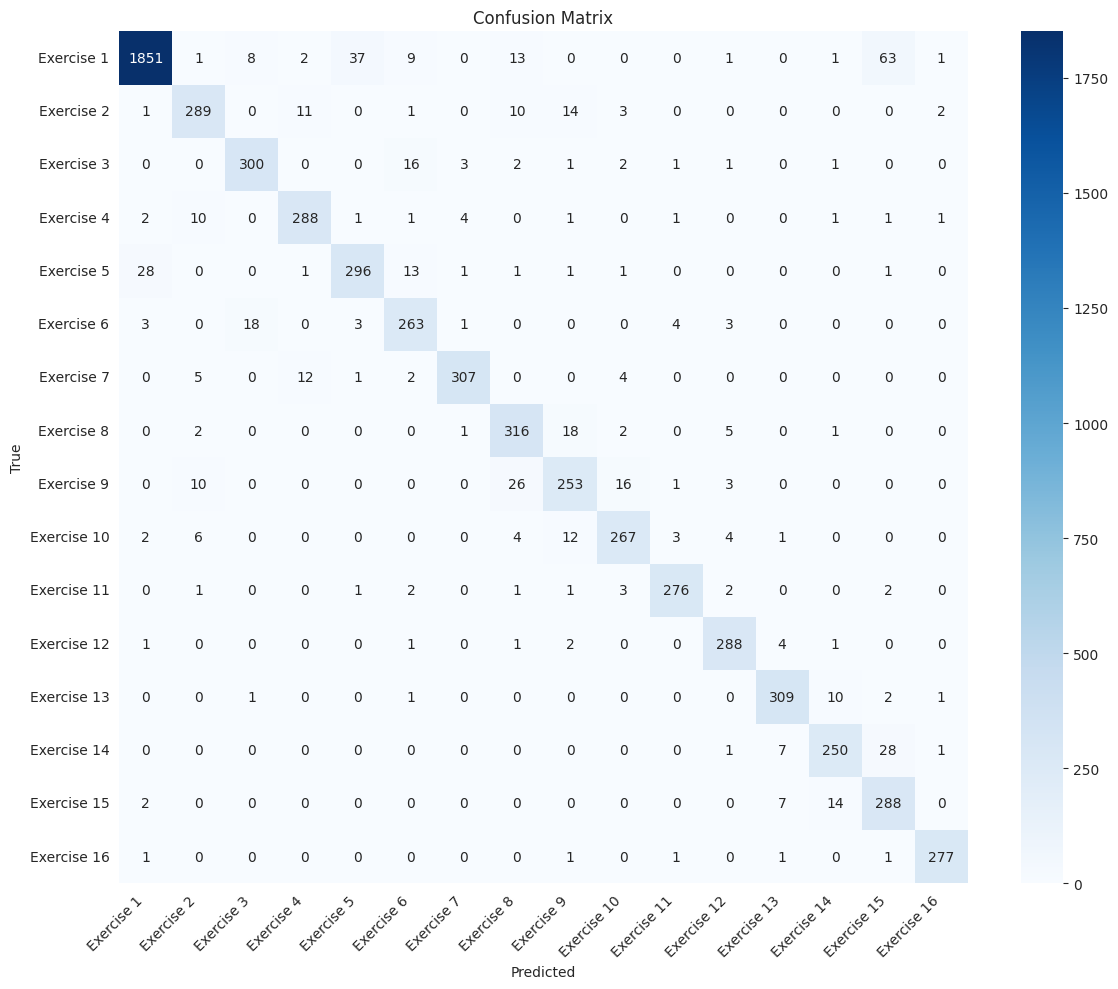

In [28]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 9. Save Model

In [29]:
# Save model and metadata
model_save_path = OUTPUT_DIR / 'action_3dcnn_model.pth'

# Save complete checkpoint
checkpoint = {
    'model_state_dict': best_model_state,
    'config': CONFIG,
    'num_classes': num_classes,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'class_names': class_names,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'history': history
}

torch.save(checkpoint, model_save_path)
print(f"Model saved to: {model_save_path}")

# Also save just the model weights for easier loading
weights_save_path = OUTPUT_DIR / 'action_3dcnn_weights.pth'
torch.save(best_model_state, weights_save_path)
print(f"Weights saved to: {weights_save_path}")

Model saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/action_3dcnn_model.pth
Weights saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/action_3dcnn_weights.pth


## 10. Grad-CAM Visualization

Grad-CAM (Gradient-weighted Class Activation Mapping) visualizes which regions of the input data are most important for the model's prediction. For skeleton-based action recognition, this helps us understand which temporal segments and keypoints contribute most to classifying each exercise.

In [30]:
class GradCAM:
    """Grad-CAM implementation for 3D-CNN action recognition model.

    Generates heatmaps showing which temporal-keypoint regions
    are most important for predictions.
    """

    def __init__(self, model, target_layer_idx=-1):
        """
        Args:
            model: The Action3DCNN model
            target_layer_idx: Index of the conv layer to use for CAM (-1 = last)
        """
        self.model = model
        self.target_layer_idx = target_layer_idx
        self.gradients = None
        self.activations = None
        self.hook_handles = []

        # Register hooks
        self._register_hooks()

    def _register_hooks(self):
        """Register forward and backward hooks on target layer."""
        target_layer = self.model.conv_layers[self.target_layer_idx]

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hook_handles.append(target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        """Remove registered hooks."""
        for handle in self.hook_handles:
            handle.remove()

    def generate_cam(self, input_tensor, target_class=None):
        """Generate Grad-CAM heatmap for input.

        Args:
            input_tensor: Input tensor of shape (1, 3, T, K)
            target_class: Class index to compute CAM for. If None, uses predicted class.

        Returns:
            cam: Heatmap of shape (T, K)
            pred_class: Predicted class index
            pred_prob: Prediction probability
        """
        self.model.eval()

        # Enable gradients for input
        input_tensor = input_tensor.clone().requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)
        pred_probs = torch.softmax(output, dim=1)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        pred_prob = pred_probs[0, target_class].item()

        # Backward pass for target class
        self.model.zero_grad()
        target = output[0, target_class]
        target.backward()

        # Get gradients and activations
        gradients = self.gradients  # (1, C, H, W)
        activations = self.activations  # (1, C, H, W)

        # Global average pooling of gradients
        weights = gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

        # Weighted combination of activations
        cam = (weights * activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)

        # ReLU (only positive contributions)
        cam = torch.relu(cam)

        # Normalize
        cam = cam.squeeze()
        if cam.max() > 0:
            cam = cam / cam.max()

        # Resize to original input size
        cam = cam.cpu().numpy()
        cam_resized = self._resize_cam(cam, (input_tensor.shape[2], input_tensor.shape[3]))

        return cam_resized, target_class, pred_prob

    def _resize_cam(self, cam, target_size):
        """Resize CAM to target size using bilinear interpolation."""
        from scipy.ndimage import zoom

        h_ratio = target_size[0] / cam.shape[0]
        w_ratio = target_size[1] / cam.shape[1]

        cam_resized = zoom(cam, (h_ratio, w_ratio), order=1)
        return cam_resized


def visualize_gradcam_skeleton(input_data, cam, pred_class, true_class, pred_prob,
                                idx_to_label, keypoint_names=None, save_path=None):
    """Visualize Grad-CAM heatmap for skeleton sequence.

    Args:
        input_data: Input tensor of shape (3, T, K)
        cam: CAM heatmap of shape (T, K)
        pred_class: Predicted class index
        true_class: True class index
        pred_prob: Prediction probability
        idx_to_label: Mapping from index to original label
        keypoint_names: List of keypoint names
        save_path: Path to save figure (optional)
    """
    if keypoint_names is None:
        keypoint_names = ['Nose', 'L_Eye', 'R_Eye', 'L_Ear', 'R_Ear',
                          'L_Shoulder', 'R_Shoulder', 'L_Elbow', 'R_Elbow',
                          'L_Wrist', 'R_Wrist', 'L_Hip', 'R_Hip',
                          'L_Knee', 'R_Knee', 'L_Ankle', 'R_Ankle']

    fig = plt.figure(figsize=(16, 10))

    # 1. Grad-CAM heatmap over time and keypoints
    ax1 = fig.add_subplot(2, 2, 1)
    im = ax1.imshow(cam.T, aspect='auto', cmap='jet', interpolation='bilinear')
    ax1.set_xlabel('Time Frame')
    ax1.set_ylabel('Keypoint')
    ax1.set_yticks(range(len(keypoint_names)))
    ax1.set_yticklabels(keypoint_names, fontsize=8)
    ax1.set_title(f'Grad-CAM Heatmap\nPred: Exercise {idx_to_label[pred_class]} ({pred_prob:.2%}) | True: Exercise {idx_to_label[true_class]}')
    plt.colorbar(im, ax=ax1, label='Importance')

    # 2. Temporal importance (mean over keypoints)
    ax2 = fig.add_subplot(2, 2, 2)
    temporal_importance = cam.mean(axis=1)
    ax2.plot(temporal_importance, color='red', linewidth=2)
    ax2.fill_between(range(len(temporal_importance)), temporal_importance, alpha=0.3, color='red')
    ax2.set_xlabel('Time Frame')
    ax2.set_ylabel('Importance')
    ax2.set_title('Temporal Importance (Mean over Keypoints)')
    ax2.grid(True, alpha=0.3)

    # 3. Keypoint importance (mean over time)
    ax3 = fig.add_subplot(2, 2, 3)
    keypoint_importance = cam.mean(axis=0)
    colors = plt.cm.jet(keypoint_importance / keypoint_importance.max())
    bars = ax3.barh(range(len(keypoint_names)), keypoint_importance, color=colors)
    ax3.set_yticks(range(len(keypoint_names)))
    ax3.set_yticklabels(keypoint_names, fontsize=8)
    ax3.set_xlabel('Importance')
    ax3.set_title('Keypoint Importance (Mean over Time)')
    ax3.grid(True, alpha=0.3, axis='x')

    # 4. Skeleton visualization with importance (middle frame)
    ax4 = fig.add_subplot(2, 2, 4)

    # Get middle frame data
    input_np = input_data.cpu().numpy()  # (3, T, K)
    mid_frame = input_np.shape[1] // 2
    x_coords = input_np[0, mid_frame, :]
    y_coords = input_np[1, mid_frame, :]
    importance = cam[mid_frame, :]

    # Skeleton connections (YOLO format)
    connections = [
        (0, 1), (0, 2), (1, 3), (2, 4),  # Head
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),  # Arms
        (5, 11), (6, 12), (11, 12),  # Torso
        (11, 13), (13, 15), (12, 14), (14, 16)  # Legs
    ]

    # Draw connections
    for i, j in connections:
        ax4.plot([x_coords[i], x_coords[j]], [y_coords[i], y_coords[j]],
                 'gray', linewidth=2, alpha=0.5)

    # Draw keypoints with importance coloring
    scatter = ax4.scatter(x_coords, y_coords, c=importance, cmap='jet',
                          s=200, edgecolors='black', linewidth=1, zorder=5)
    plt.colorbar(scatter, ax=ax4, label='Importance')

    # Add keypoint labels
    for i, name in enumerate(keypoint_names):
        ax4.annotate(name.split('_')[-1][:3], (x_coords[i], y_coords[i]),
                     fontsize=6, ha='center', va='bottom')

    ax4.set_xlim(-0.1, 1.1)
    ax4.set_ylim(1.1, -0.1)  # Invert y-axis for image coordinates
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title(f'Skeleton (Frame {mid_frame}) with Keypoint Importance')
    ax4.set_aspect('equal')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

    return fig

In [31]:
# Initialize Grad-CAM
gradcam = GradCAM(model, target_layer_idx=-1)

print("Generating Grad-CAM visualizations for sample test predictions...")

Generating Grad-CAM visualizations for sample test predictions...


In [32]:
# Select samples for visualization (one per class if possible)
samples_per_class = {}
for idx, (x, y) in enumerate(test_dataset):
    y_val = y.item()
    if y_val not in samples_per_class:
        samples_per_class[y_val] = (x, y_val, idx)
    if len(samples_per_class) >= num_classes:
        break

print(f"Found samples for {len(samples_per_class)} classes")

Found samples for 16 classes



Sample from class 0 (Exercise 1)
  True class: Exercise 1
  Predicted class: Exercise 1 (98.06%)
  Correct: ✓


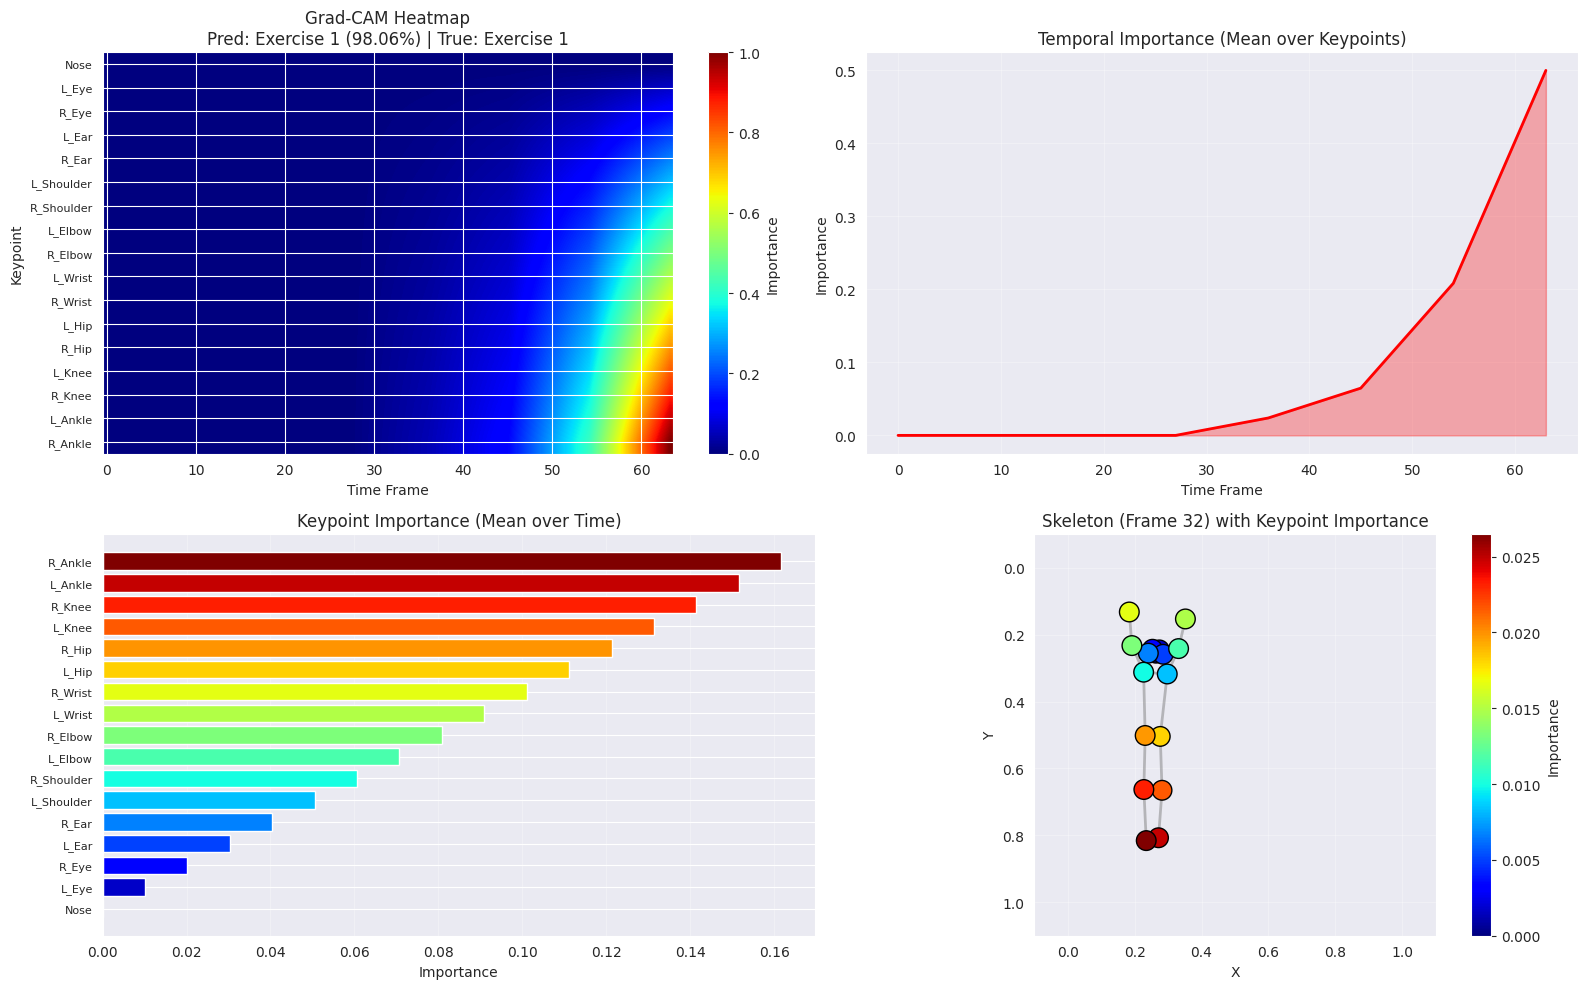


Sample from class 1 (Exercise 2)
  True class: Exercise 2
  Predicted class: Exercise 2 (100.00%)
  Correct: ✓


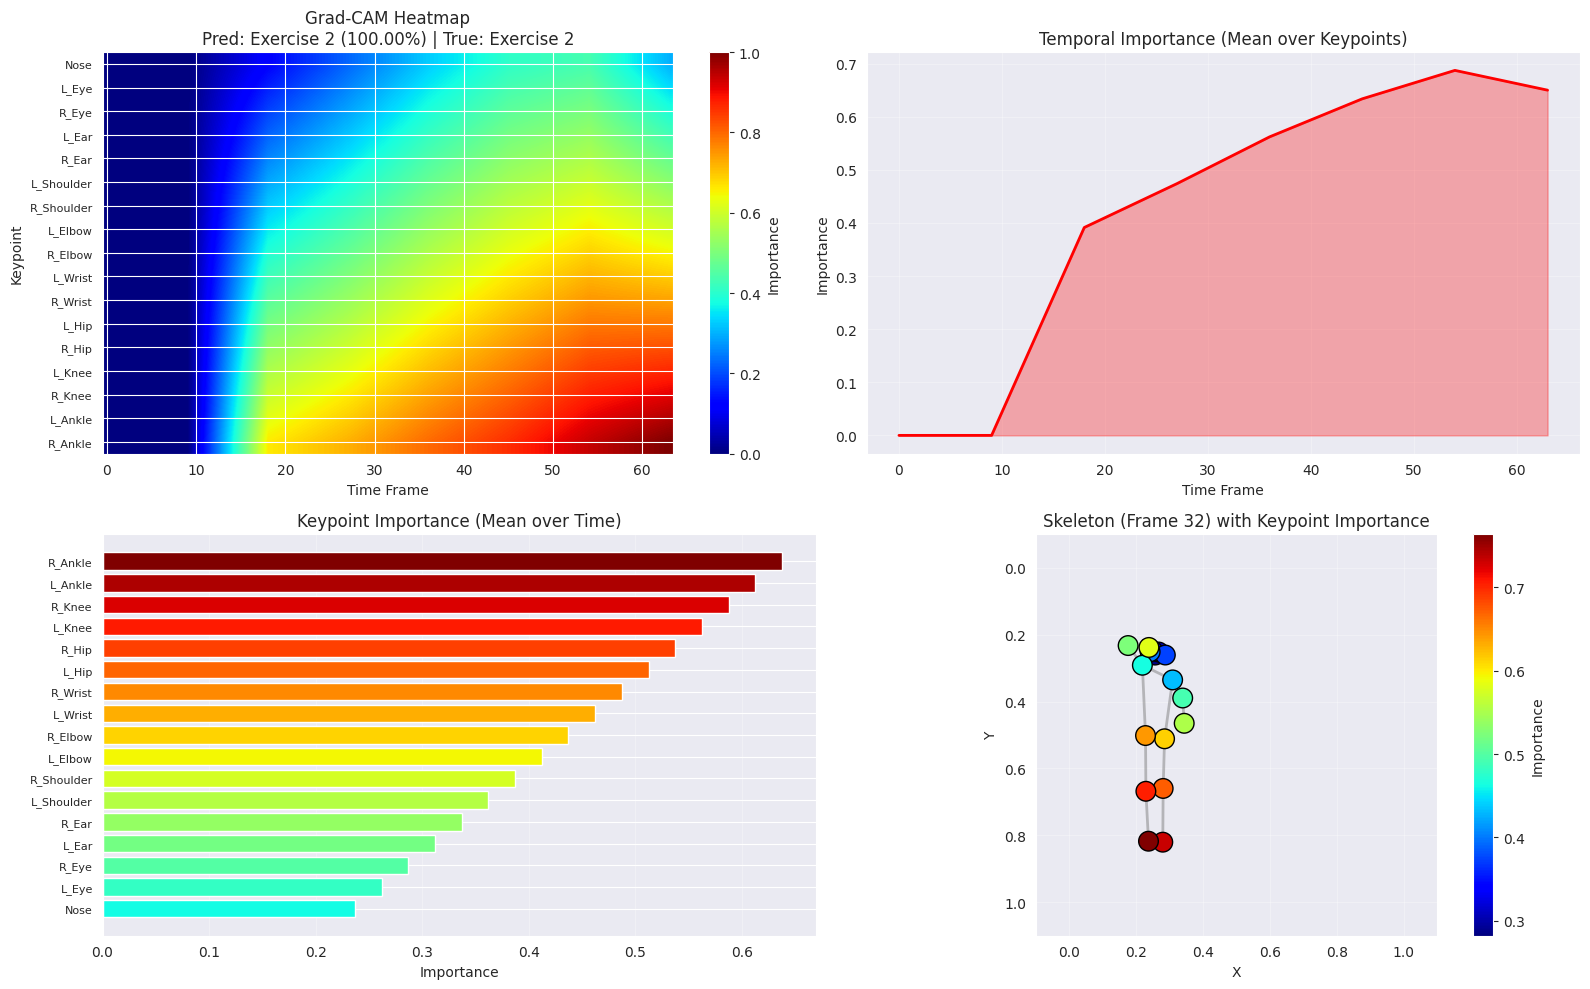


Sample from class 2 (Exercise 3)
  True class: Exercise 3
  Predicted class: Exercise 3 (99.97%)
  Correct: ✓


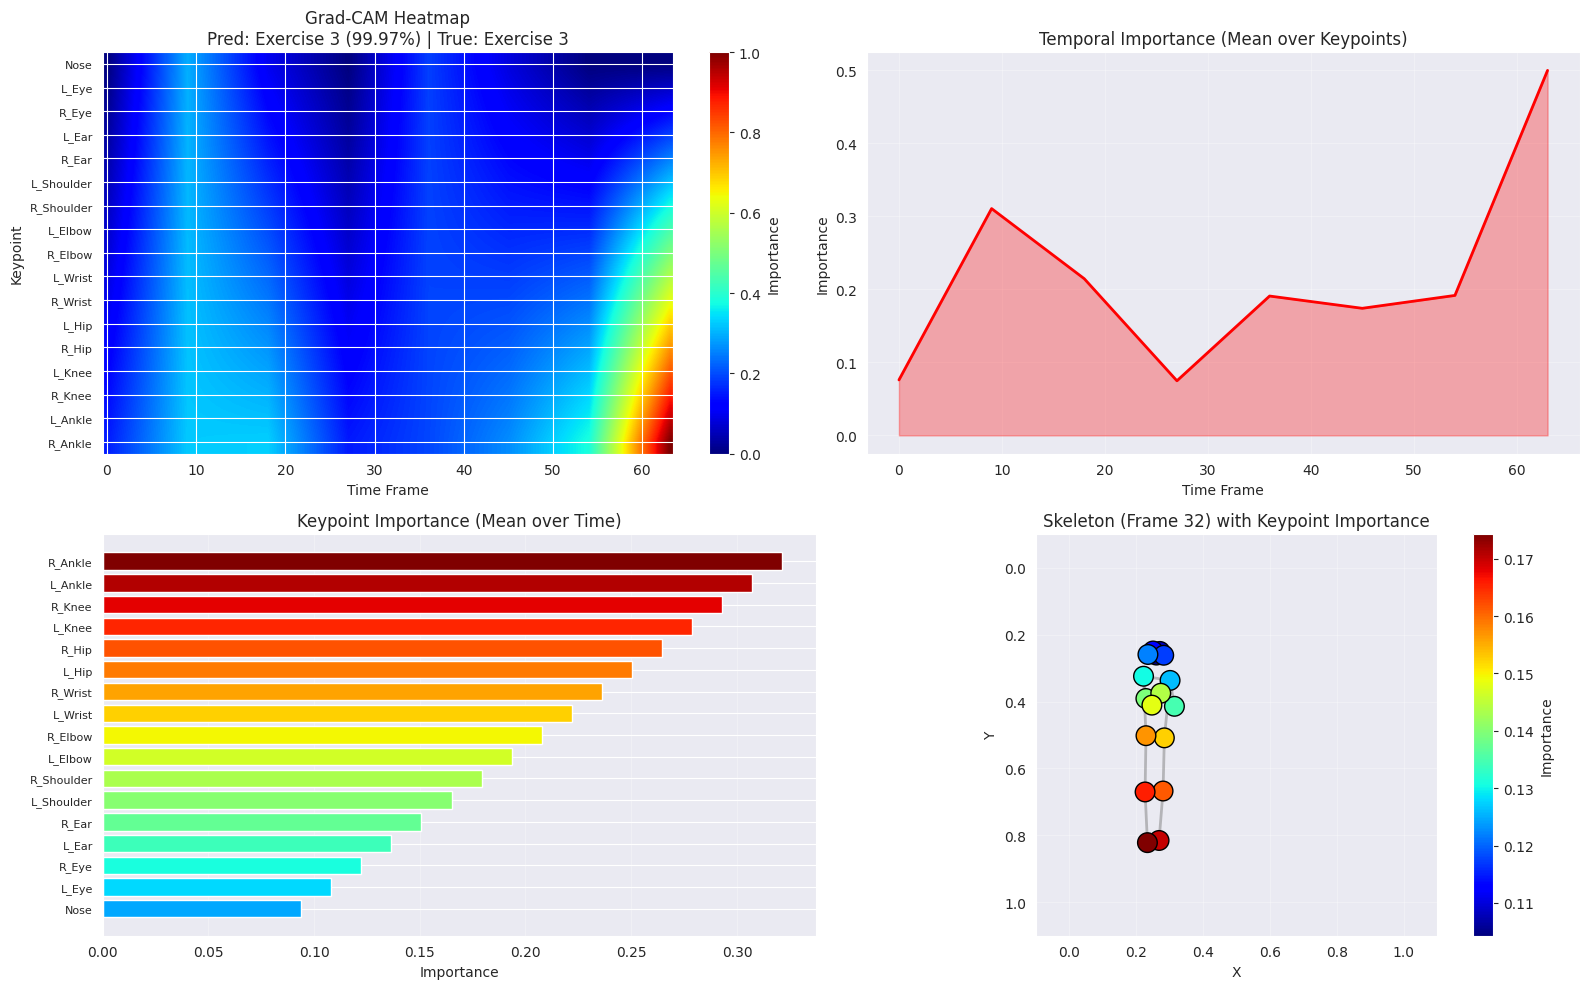


Sample from class 3 (Exercise 4)
  True class: Exercise 4
  Predicted class: Exercise 4 (100.00%)
  Correct: ✓


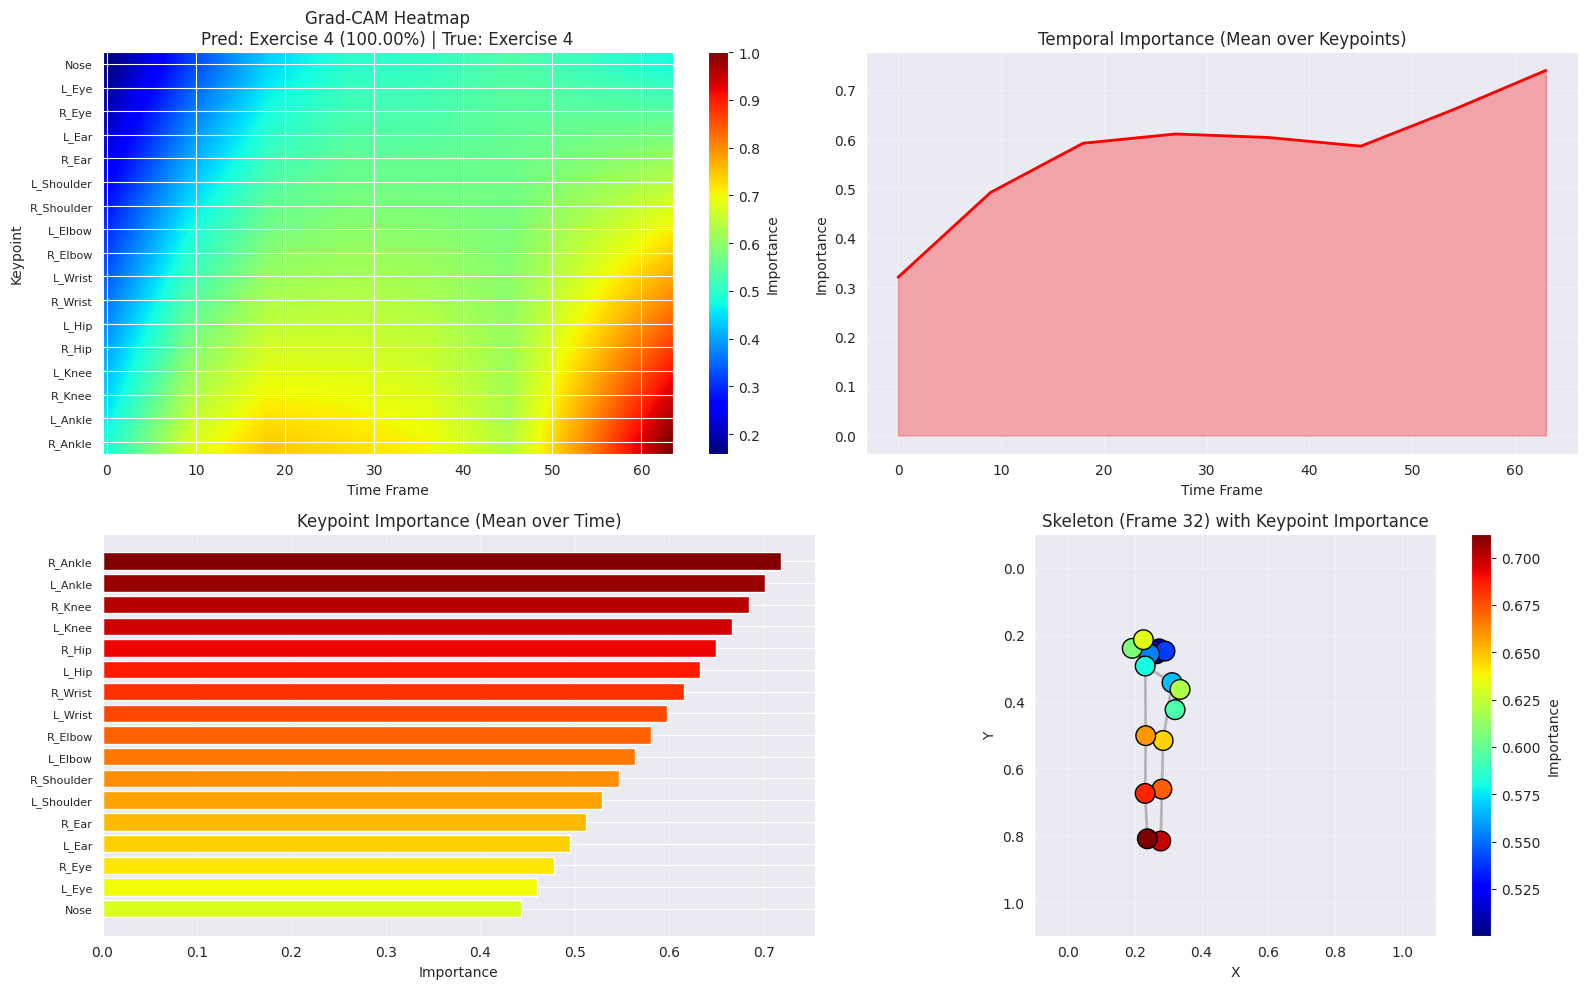


Sample from class 4 (Exercise 5)
  True class: Exercise 5
  Predicted class: Exercise 1 (99.40%)
  Correct: ✗


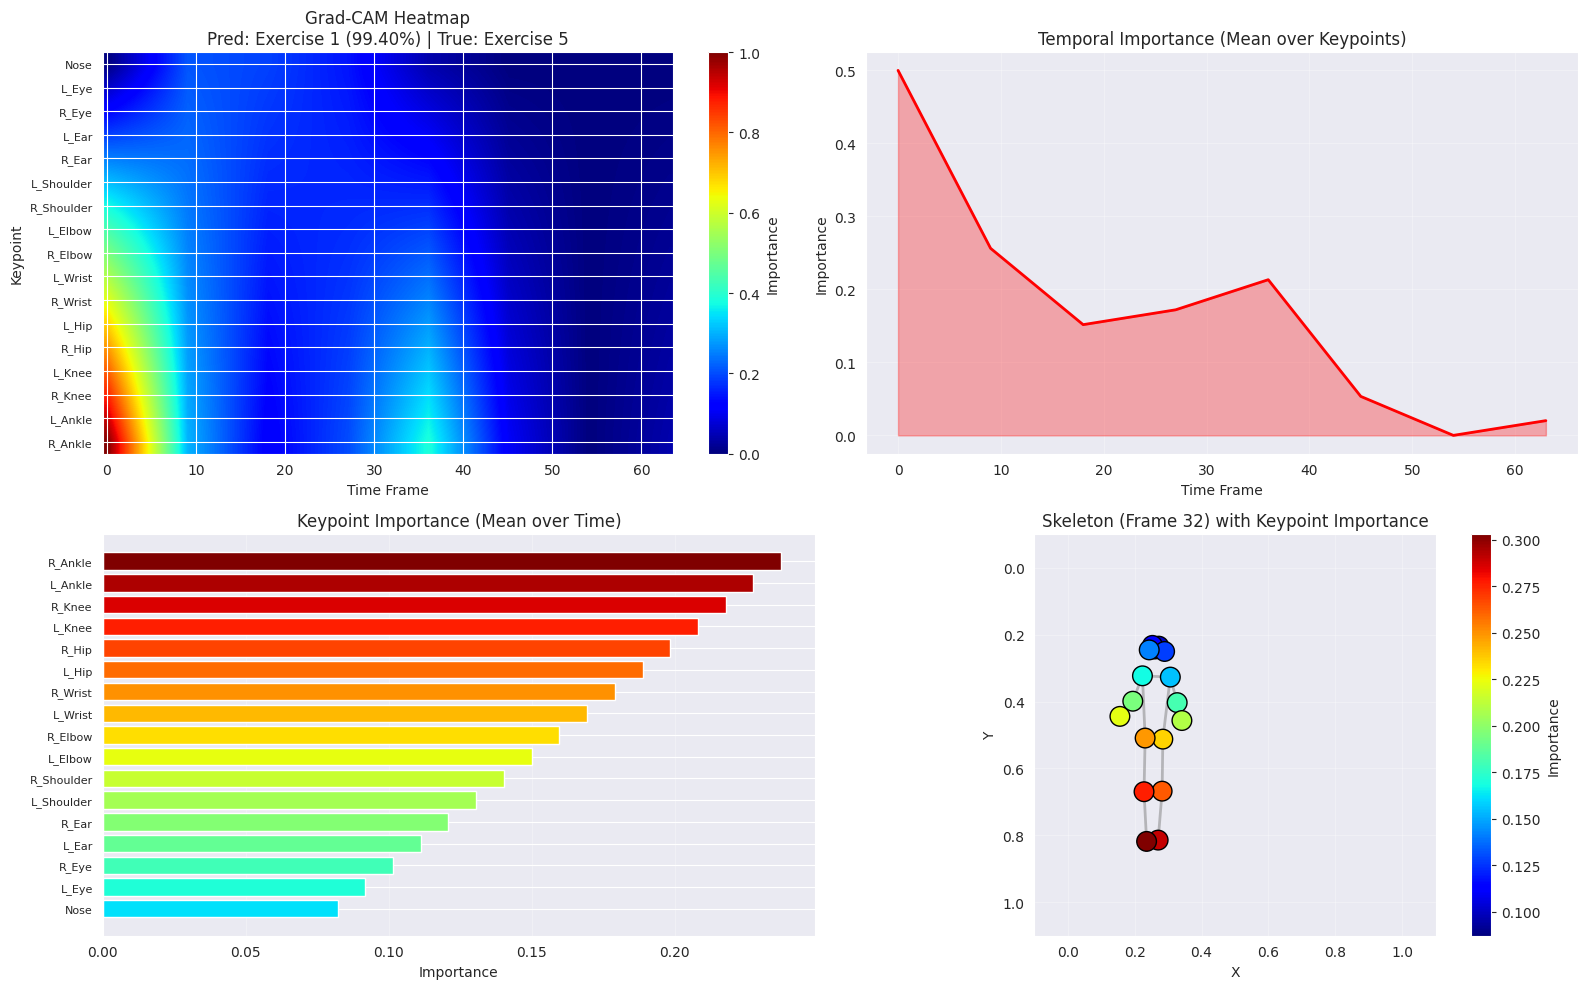


Sample from class 6 (Exercise 7)
  True class: Exercise 7
  Predicted class: Exercise 7 (99.97%)
  Correct: ✓


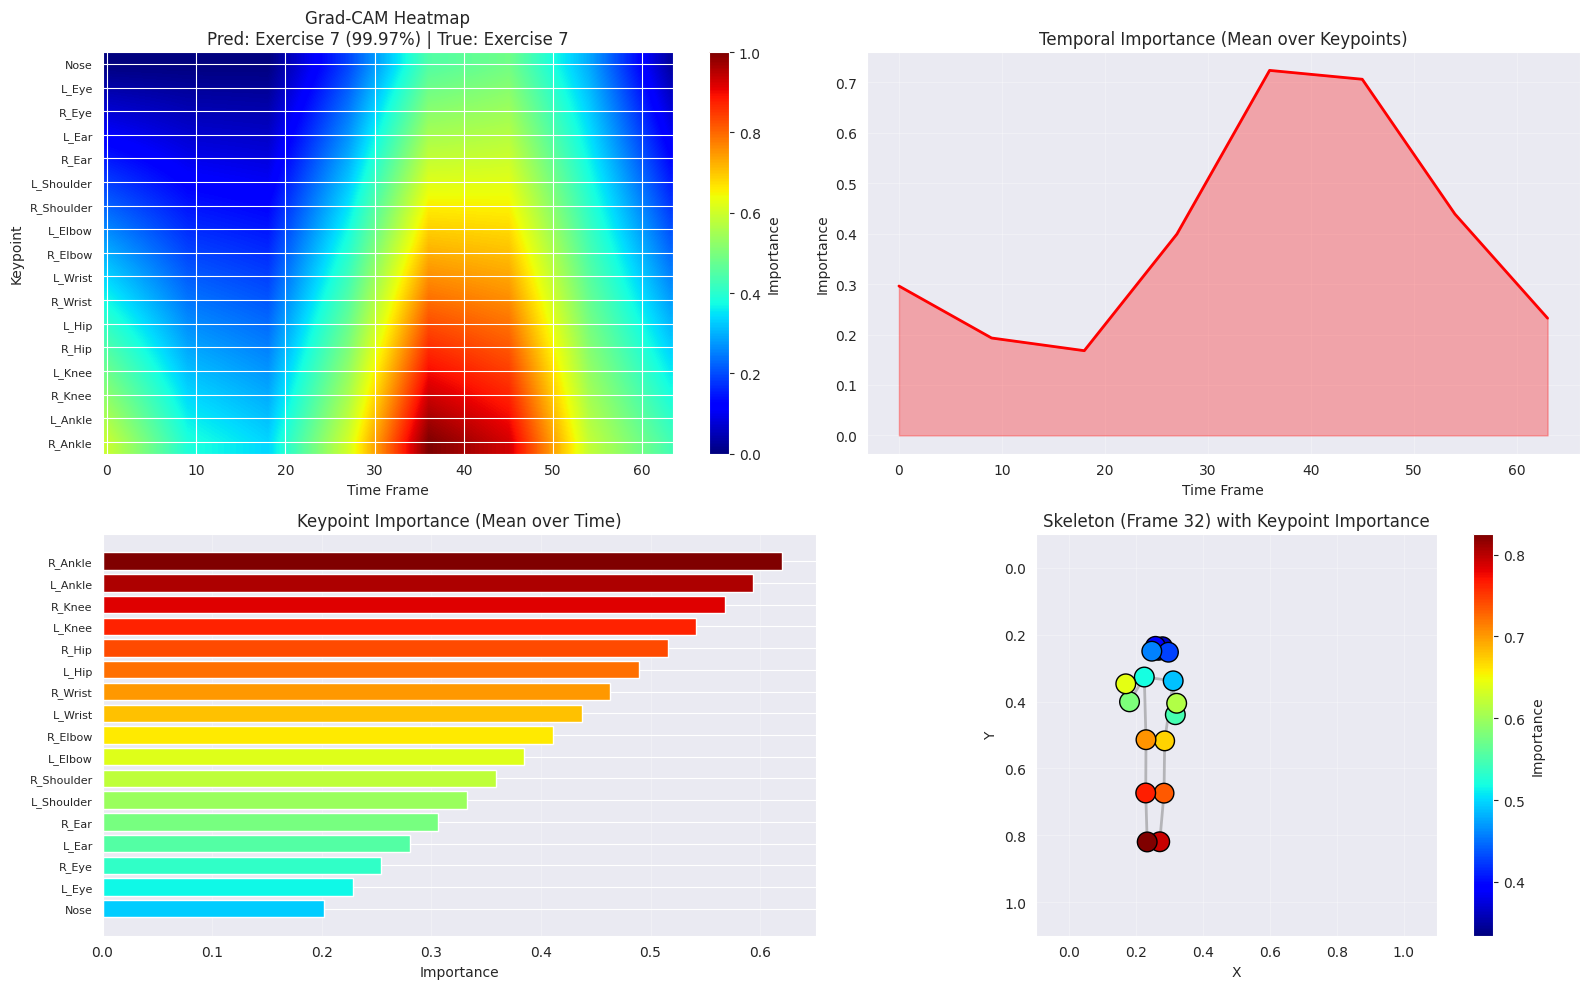


Sample from class 7 (Exercise 8)
  True class: Exercise 8
  Predicted class: Exercise 8 (98.99%)
  Correct: ✓


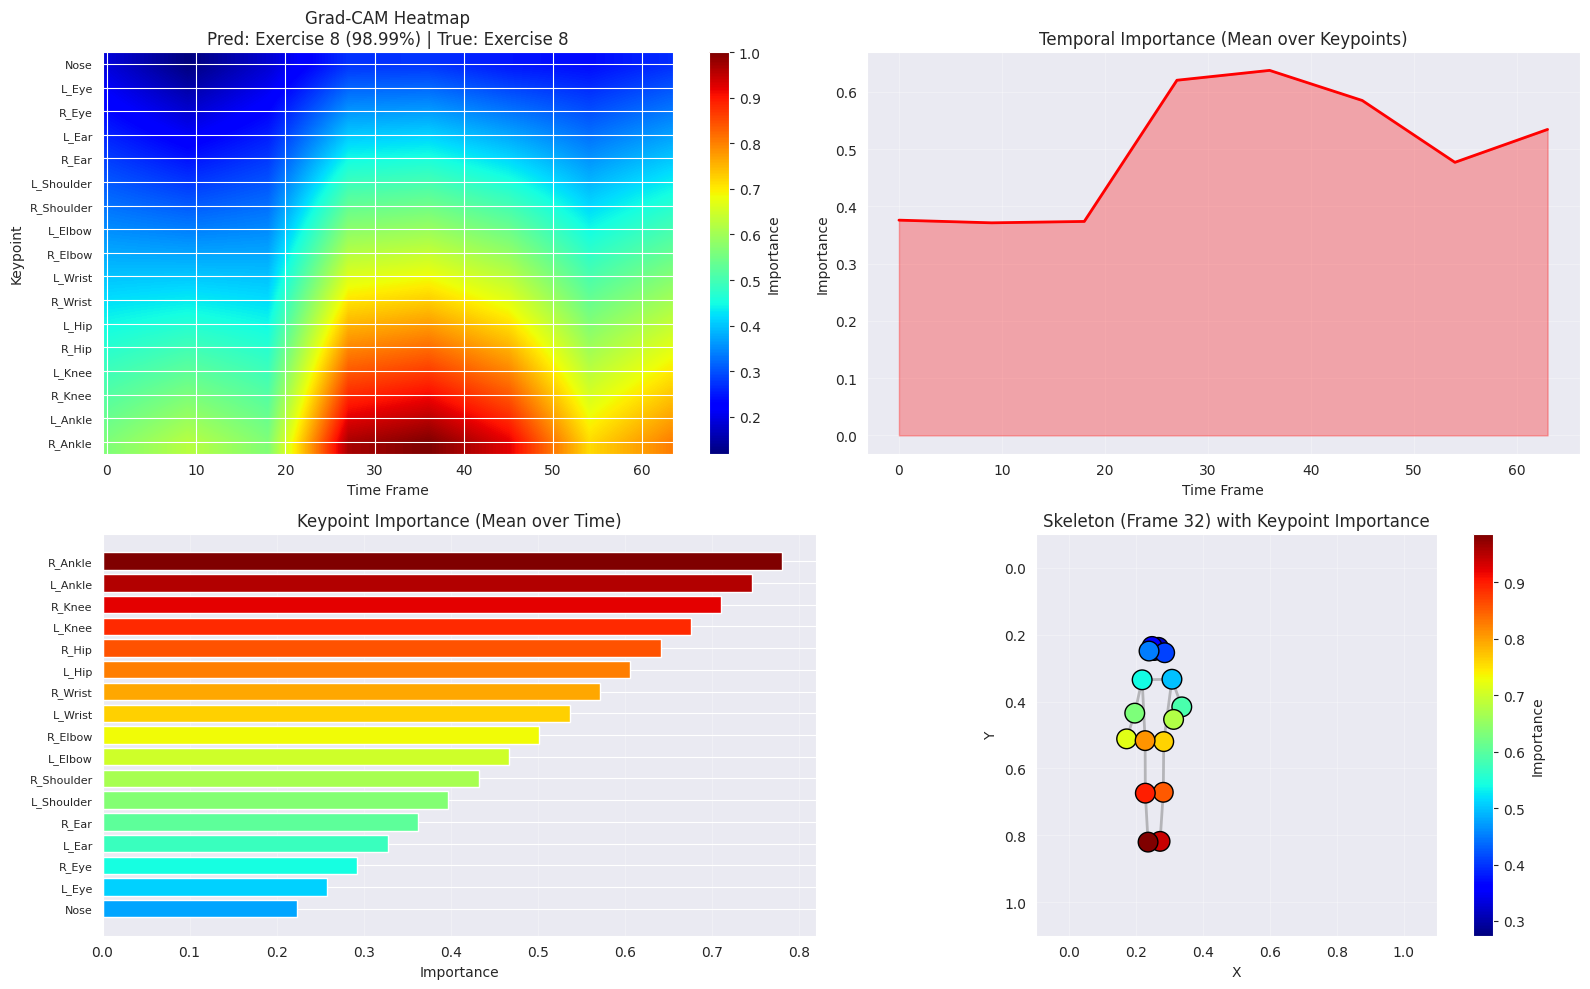


Sample from class 8 (Exercise 9)
  True class: Exercise 9
  Predicted class: Exercise 9 (95.48%)
  Correct: ✓


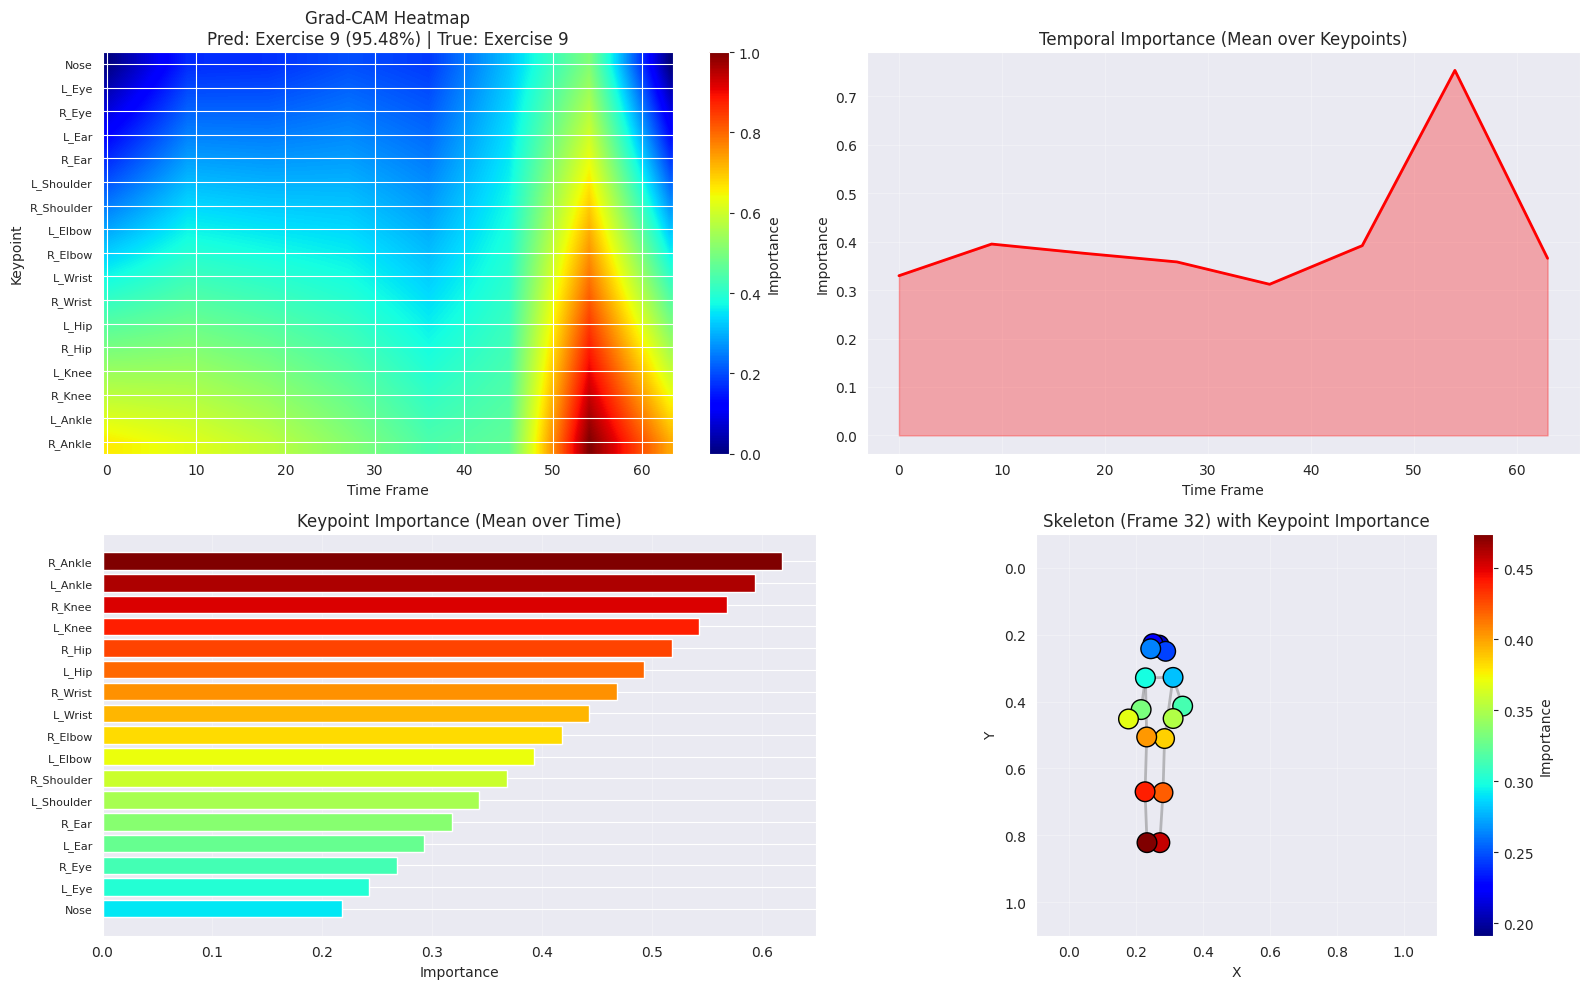


Sample from class 9 (Exercise 10)
  True class: Exercise 10
  Predicted class: Exercise 10 (73.99%)
  Correct: ✓


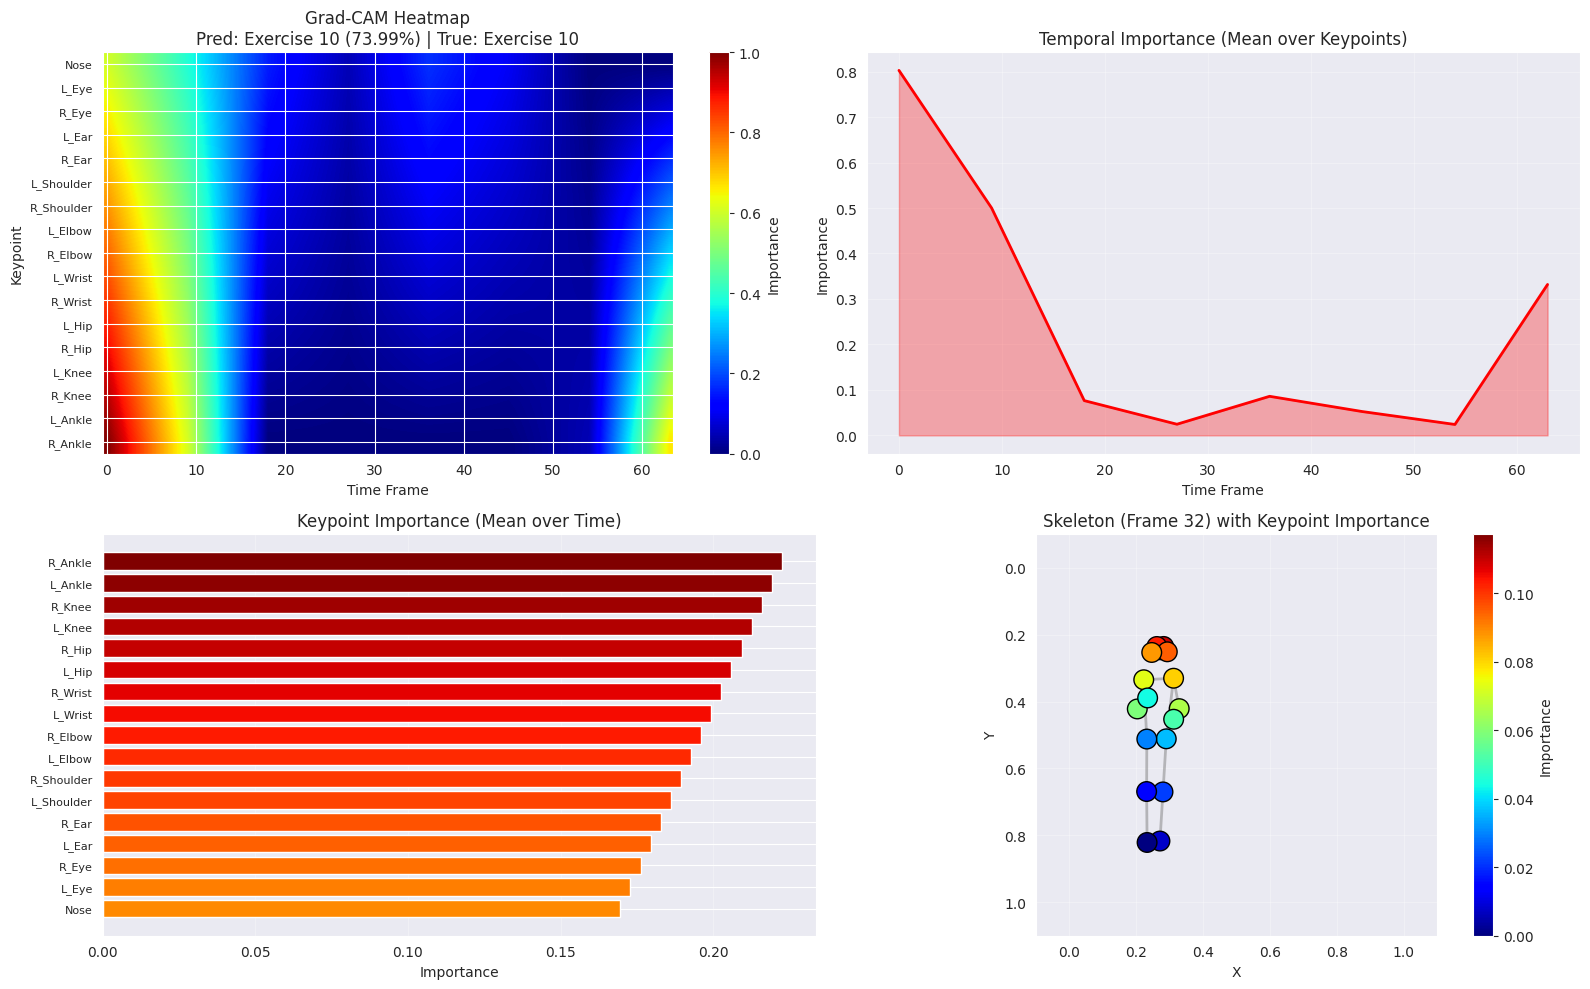


Sample from class 10 (Exercise 11)
  True class: Exercise 11
  Predicted class: Exercise 2 (58.95%)
  Correct: ✗


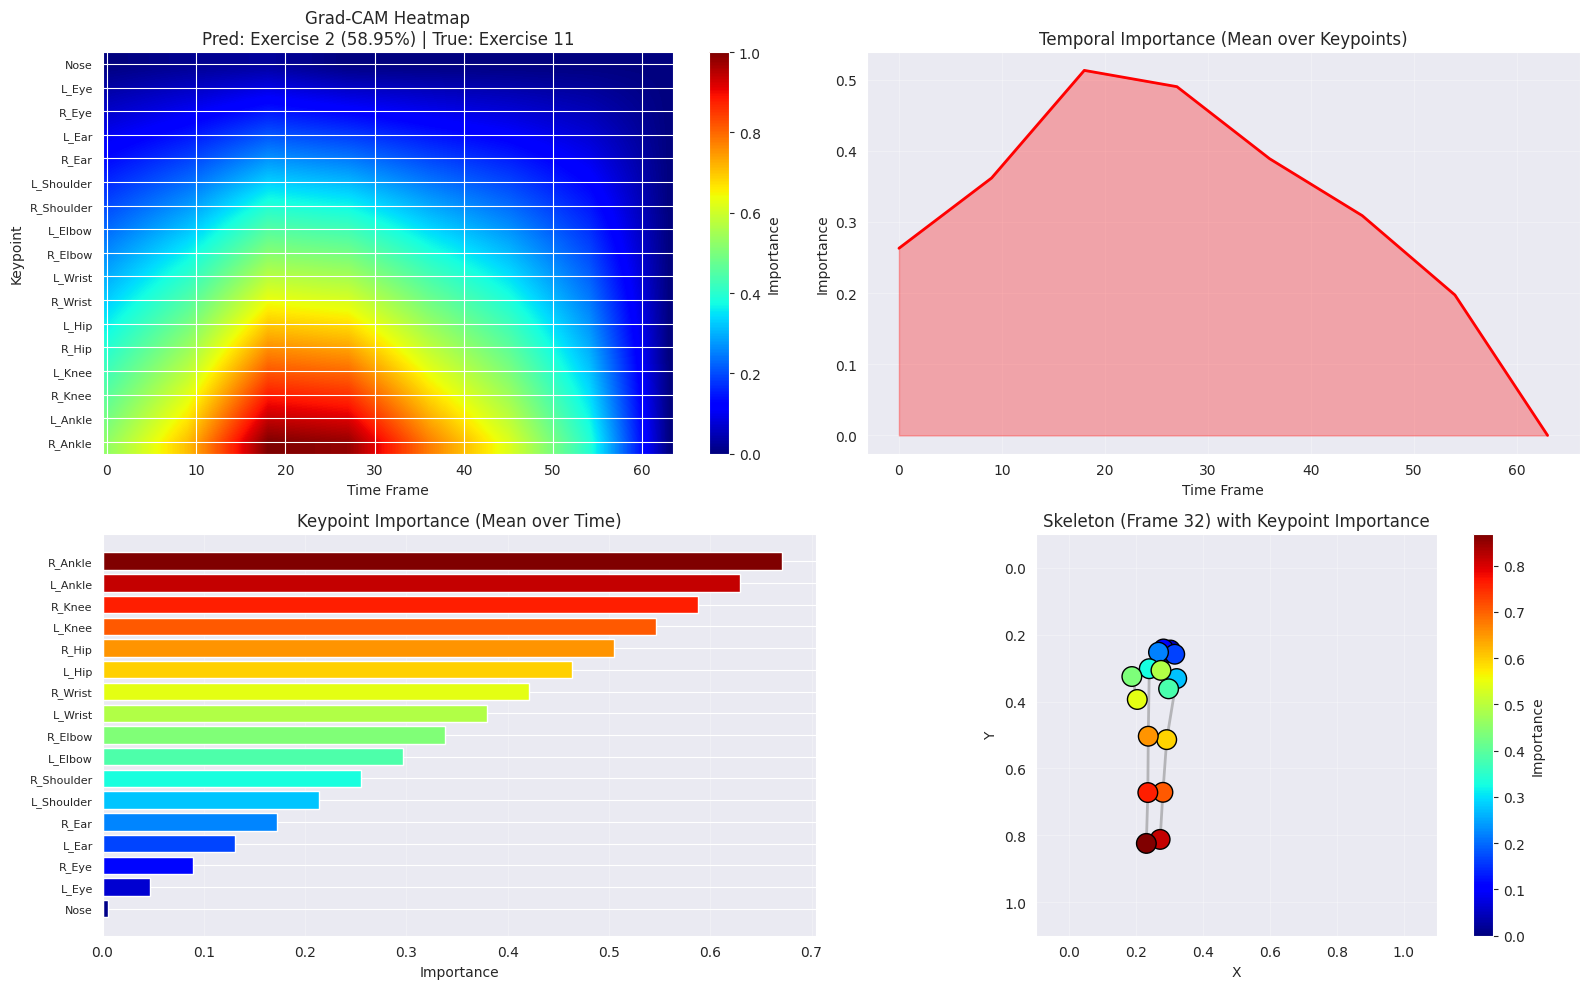


Sample from class 11 (Exercise 12)
  True class: Exercise 12
  Predicted class: Exercise 12 (99.78%)
  Correct: ✓


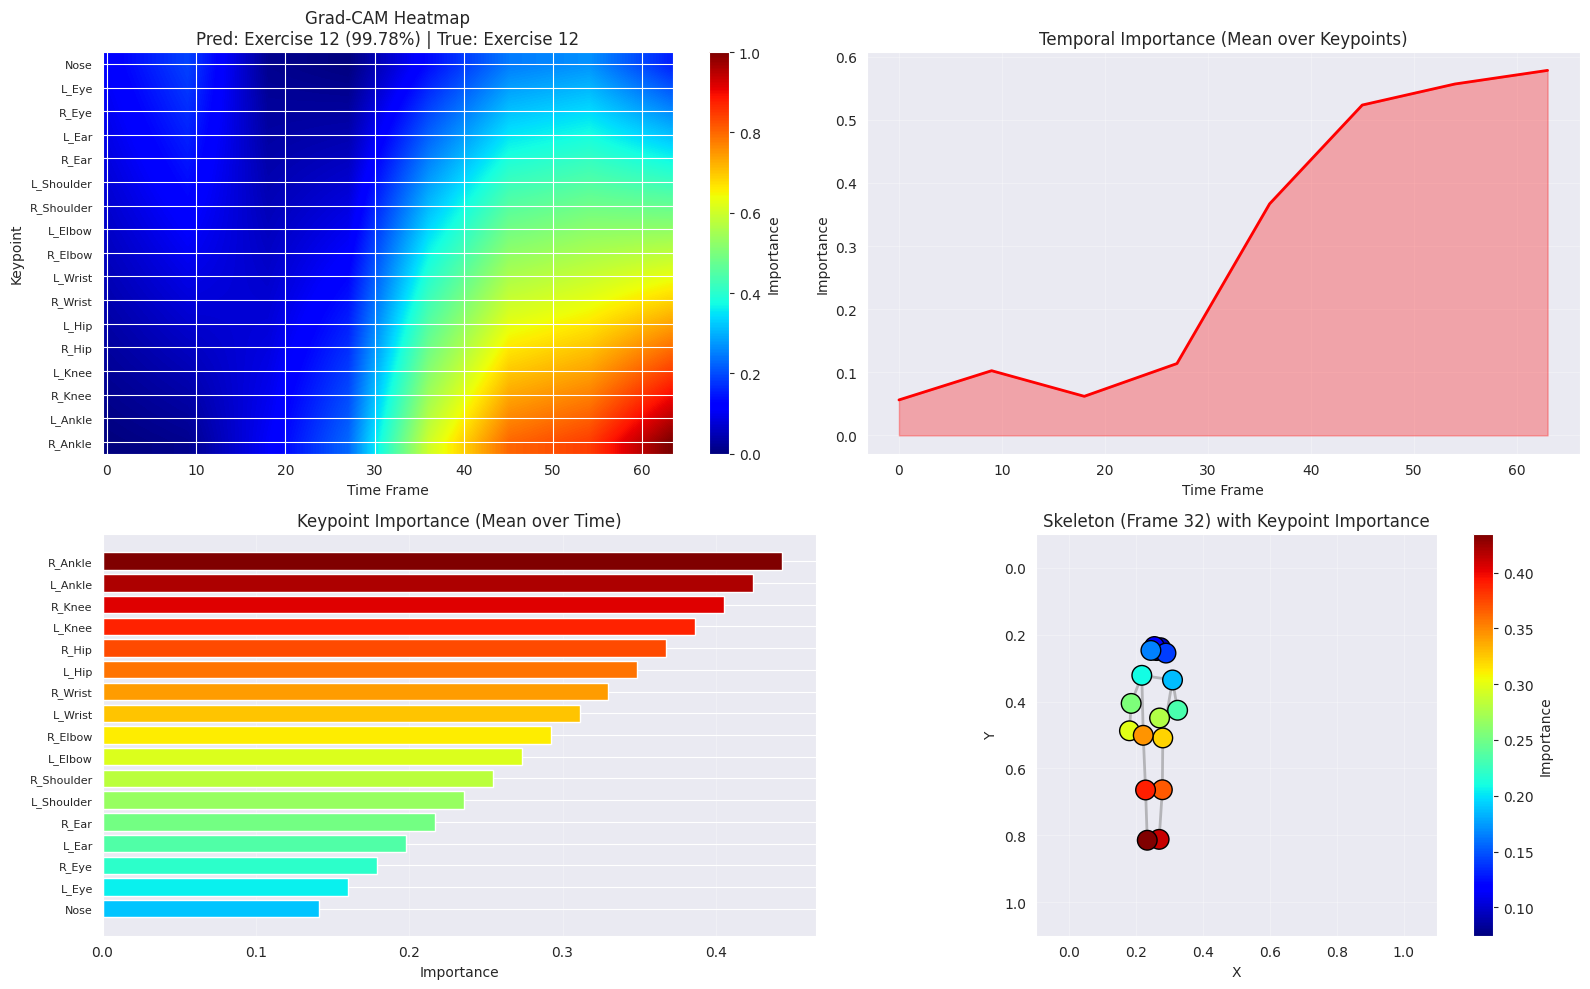


Sample from class 12 (Exercise 13)
  True class: Exercise 13
  Predicted class: Exercise 6 (45.74%)
  Correct: ✗


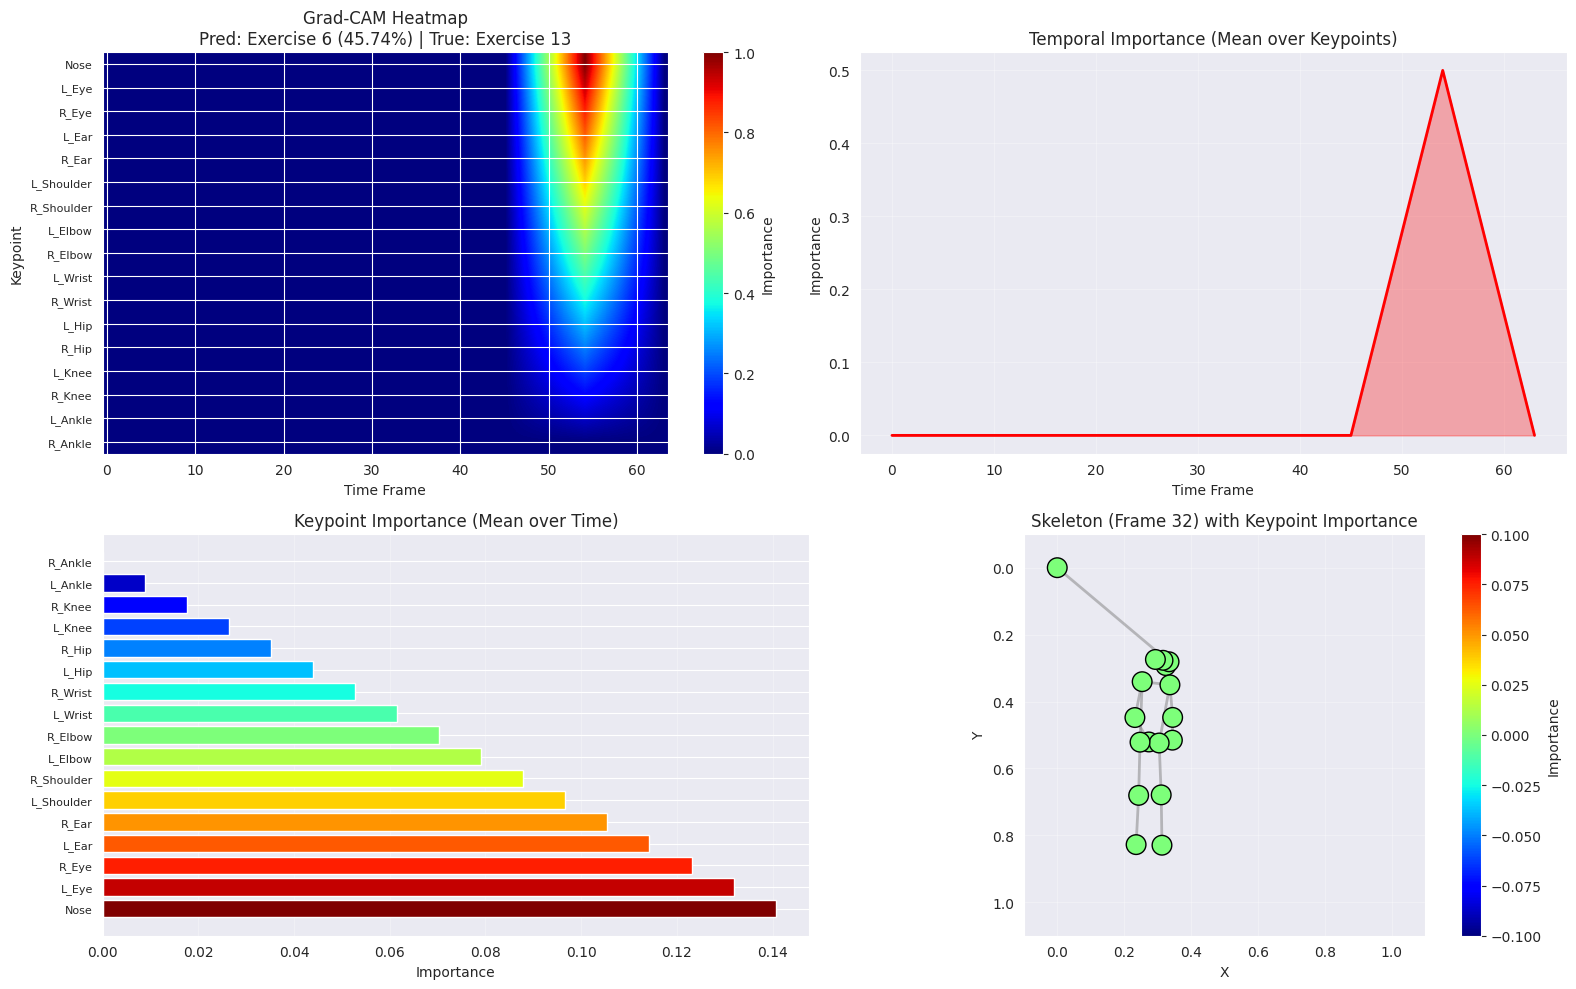


Sample from class 13 (Exercise 14)
  True class: Exercise 14
  Predicted class: Exercise 14 (99.96%)
  Correct: ✓


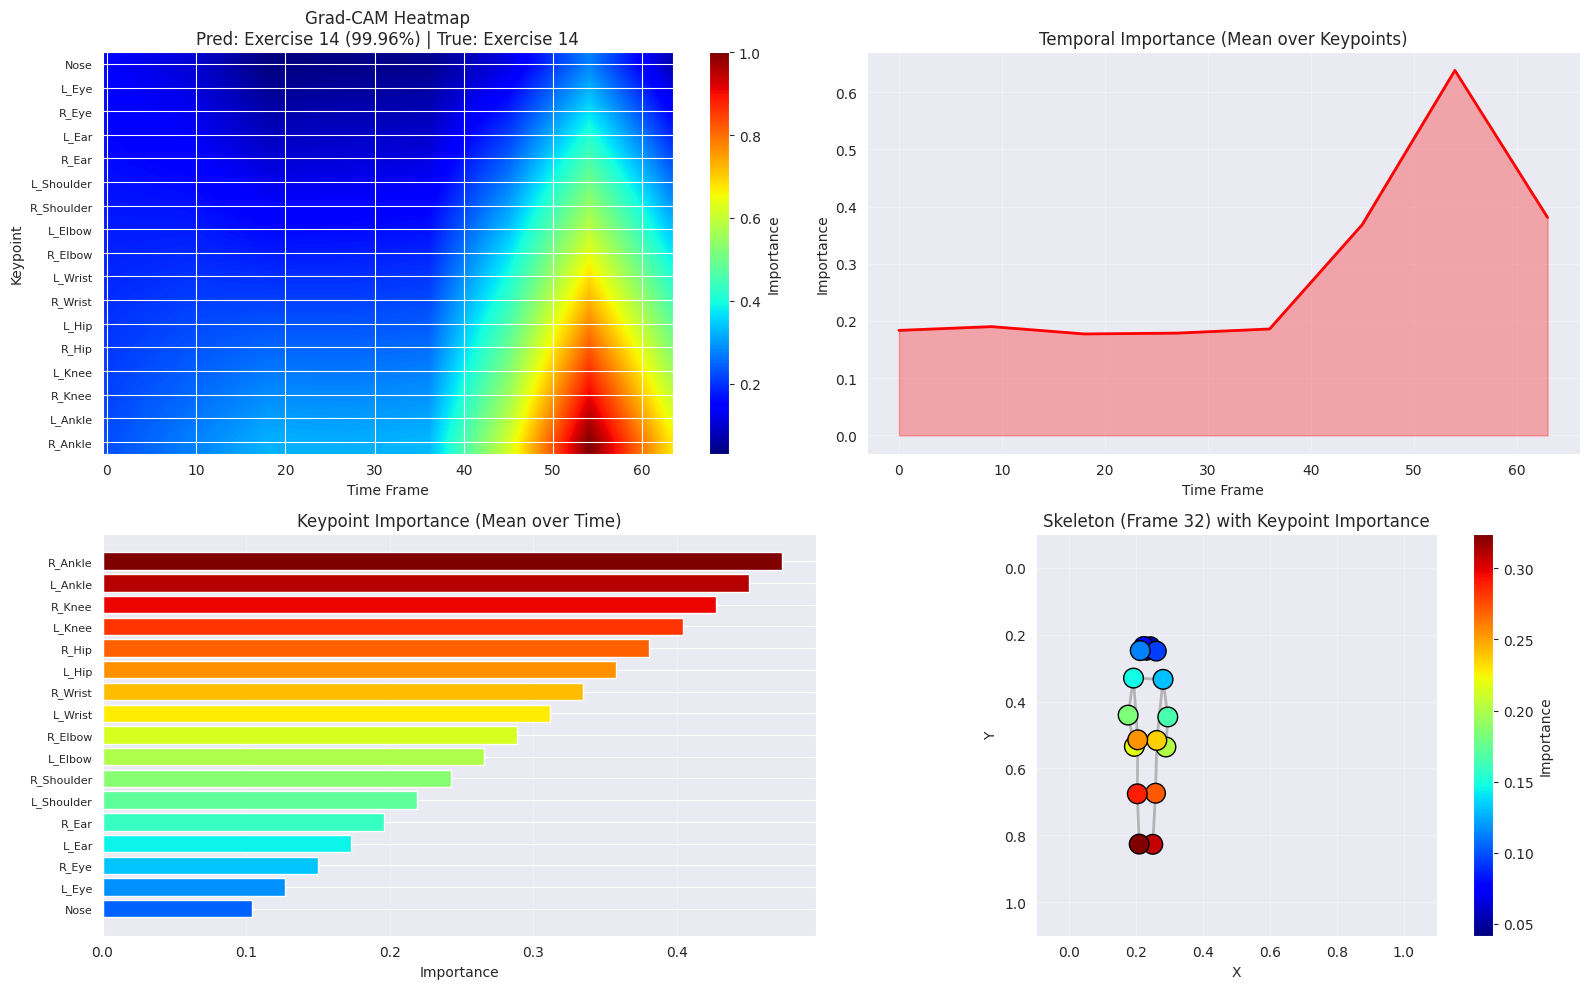


Sample from class 14 (Exercise 15)
  True class: Exercise 15
  Predicted class: Exercise 15 (99.07%)
  Correct: ✓


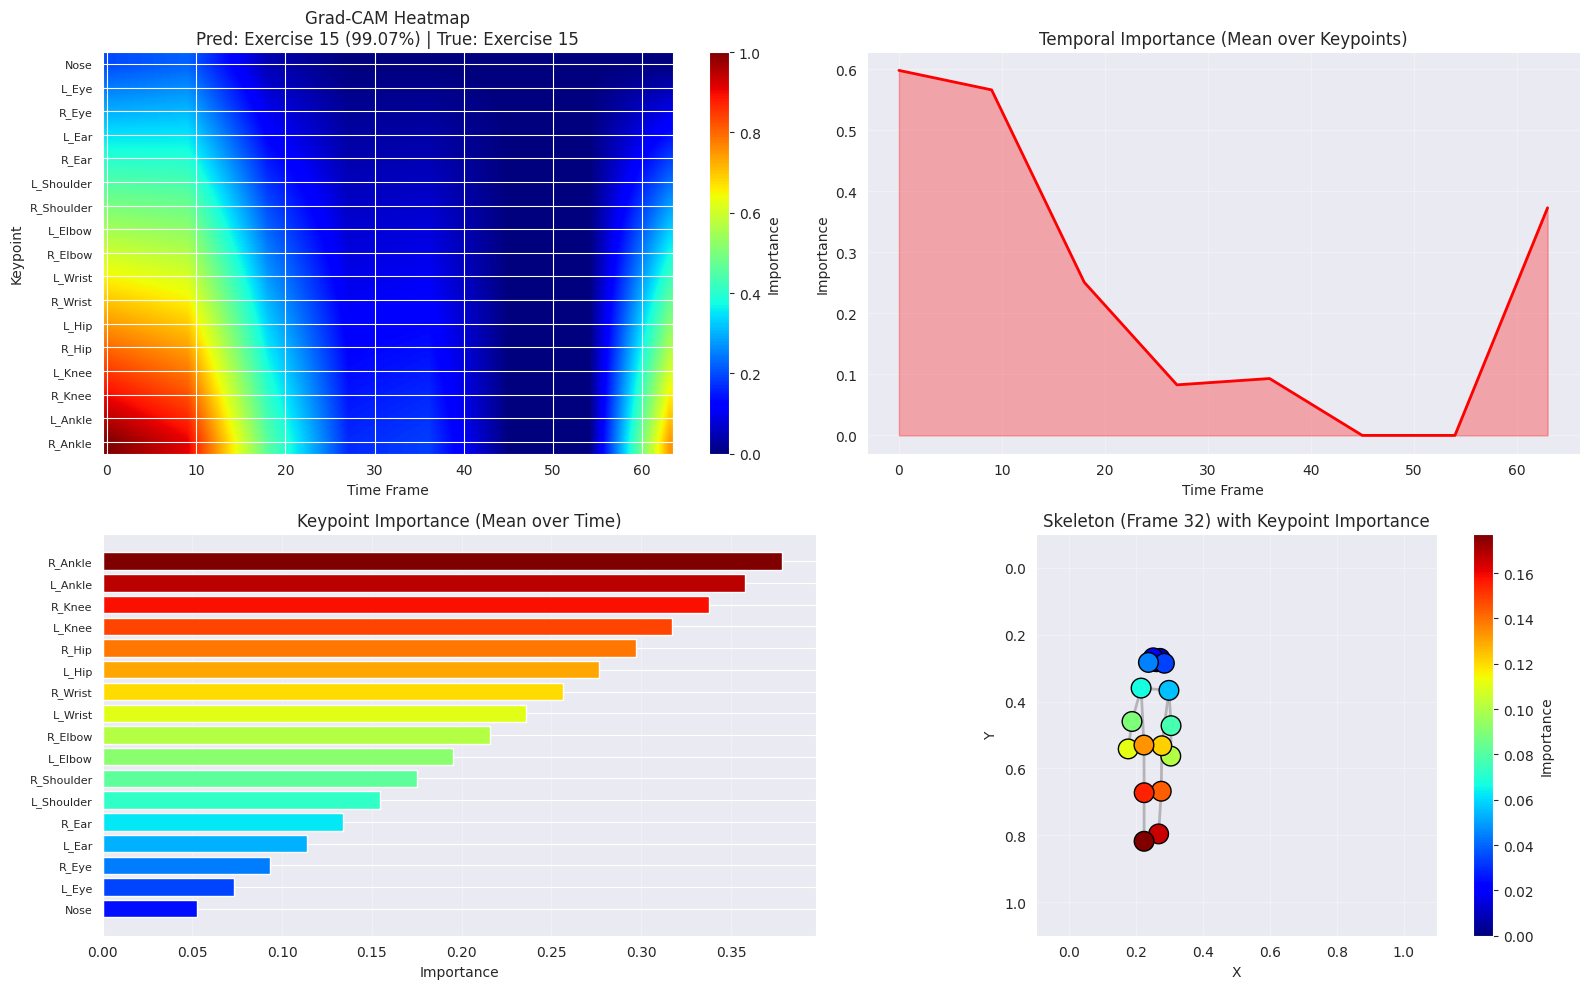


Sample from class 15 (Exercise 16)
  True class: Exercise 16
  Predicted class: Exercise 1 (52.08%)
  Correct: ✗


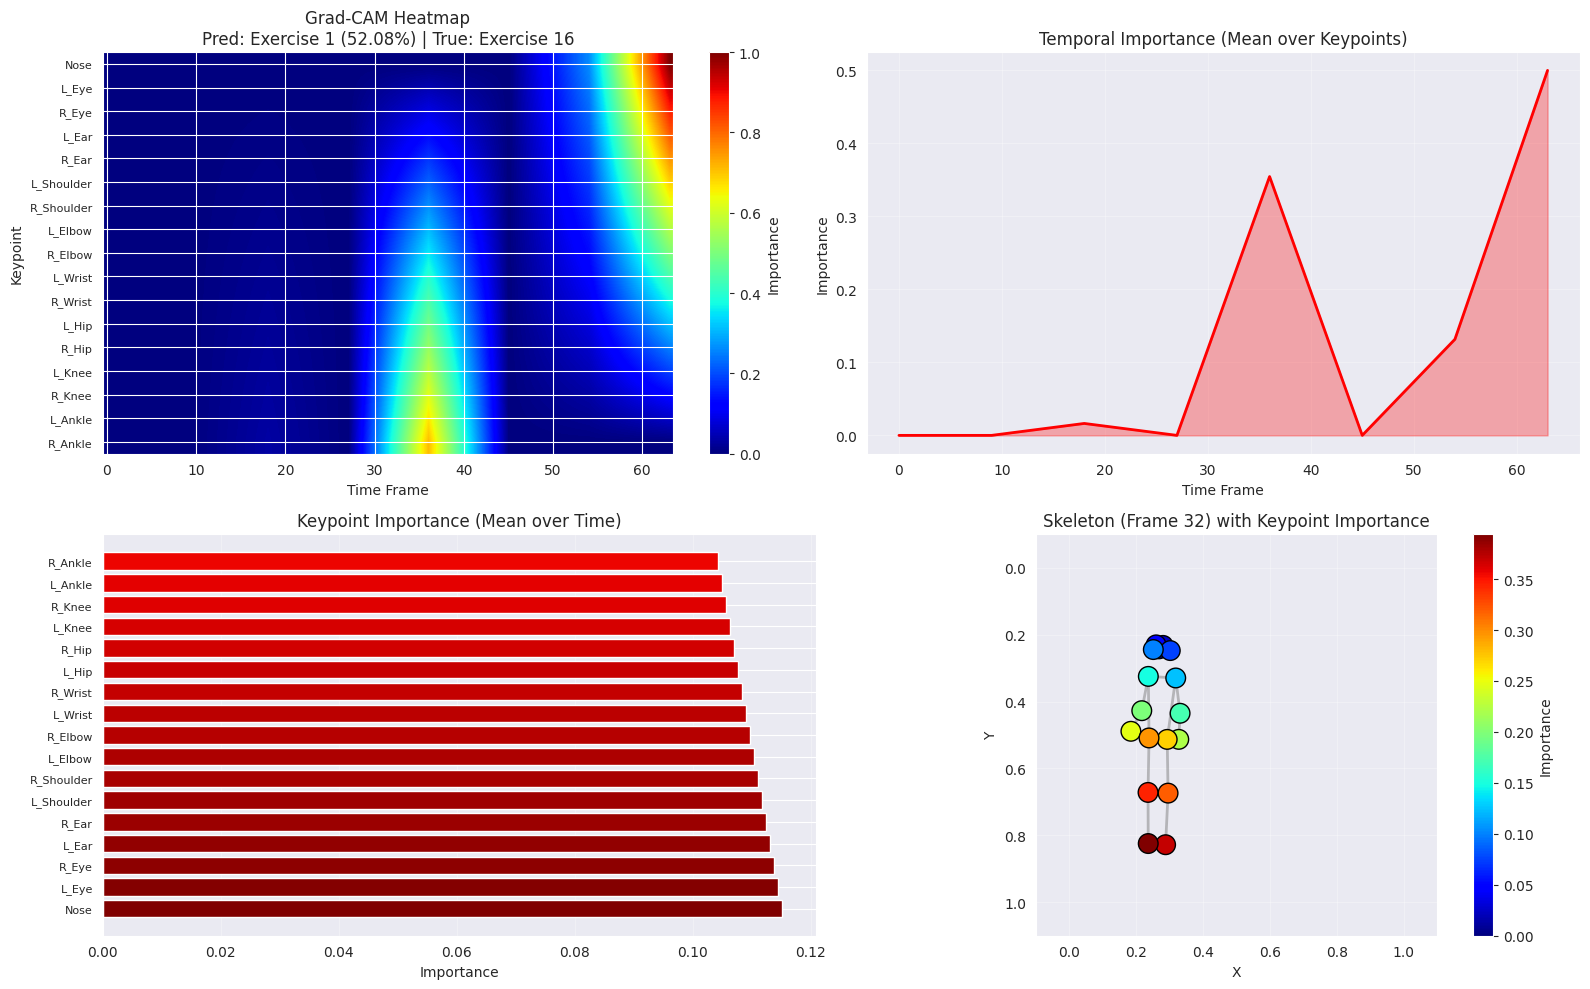


Sample from class 5 (Exercise 6)
  True class: Exercise 6
  Predicted class: Exercise 11 (90.36%)
  Correct: ✗


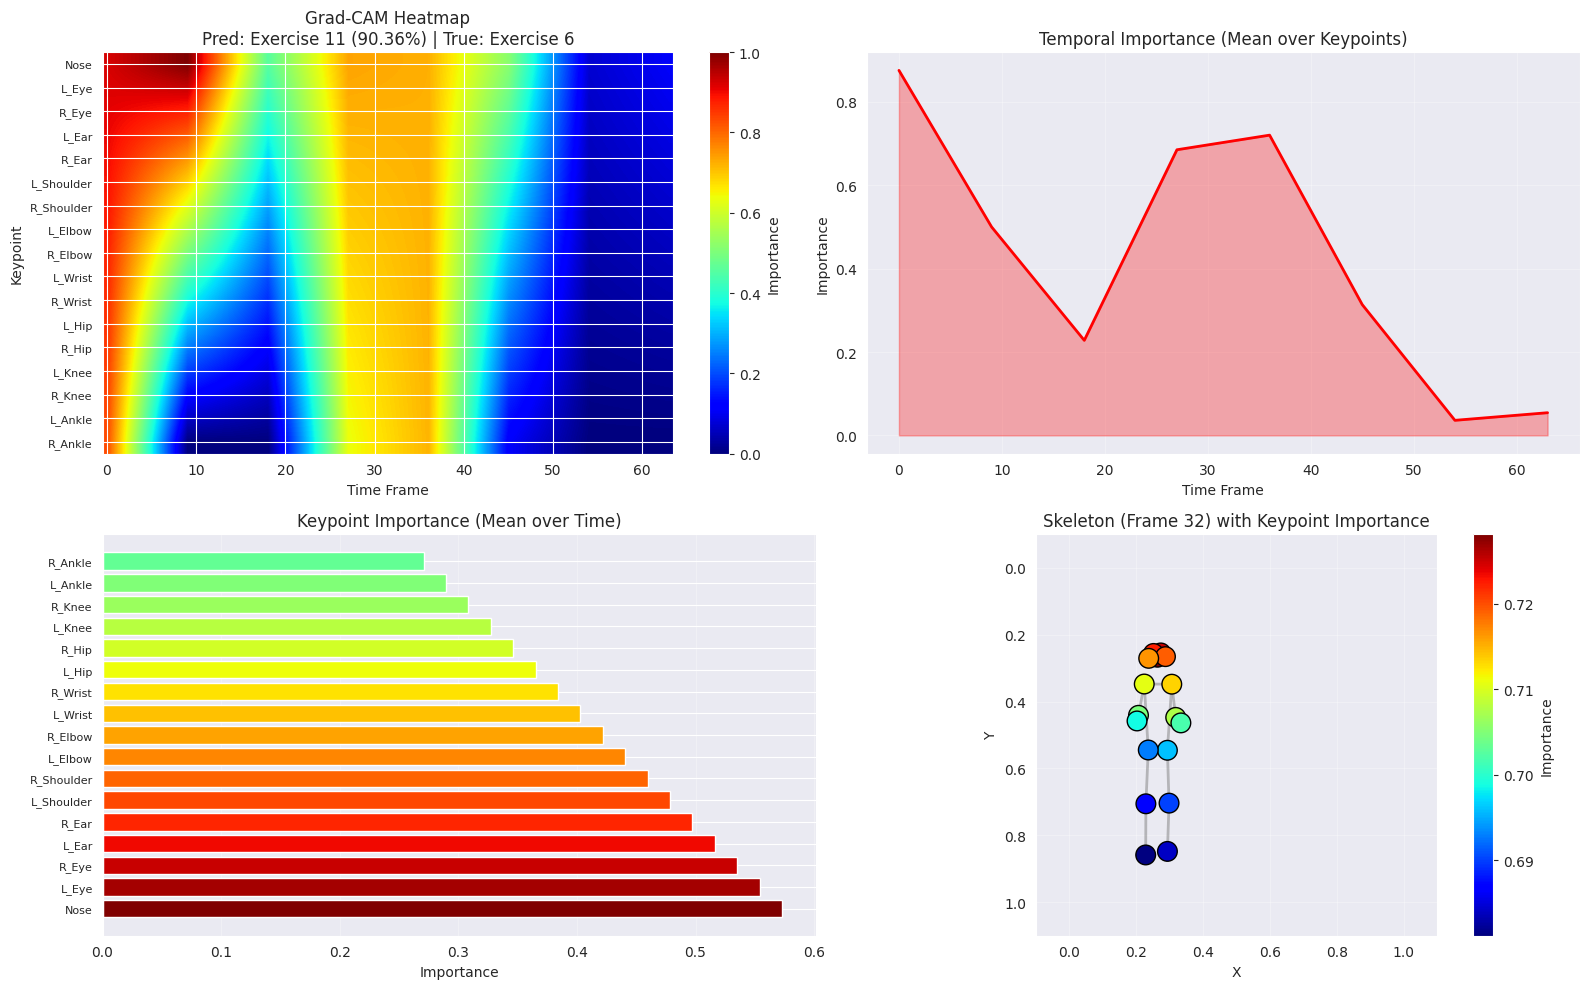


Grad-CAM visualizations saved to: /net/afscra/people/plgmateuszoracz/wk/project/output


In [33]:
# Generate and visualize Grad-CAM for each sample
gradcam_results = []

for class_idx, (x, true_class, sample_idx) in samples_per_class.items():
    print(f"\n{'='*60}")
    print(f"Sample from class {class_idx} (Exercise {idx_to_label[class_idx]})")
    print(f"{'='*60}")

    # Prepare input
    input_tensor = x.unsqueeze(0).to(device)

    # Generate Grad-CAM
    cam, pred_class, pred_prob = gradcam.generate_cam(input_tensor)

    print(f"  True class: Exercise {idx_to_label[true_class]}")
    print(f"  Predicted class: Exercise {idx_to_label[pred_class]} ({pred_prob:.2%})")
    print(f"  Correct: {'✓' if pred_class == true_class else '✗'}")

    # Save path
    save_path = OUTPUT_DIR / f'gradcam_class_{idx_to_label[class_idx]}.png'

    # Visualize
    visualize_gradcam_skeleton(
        x, cam, pred_class, true_class, pred_prob,
        idx_to_label, save_path=save_path
    )

    gradcam_results.append({
        'true_class': true_class,
        'pred_class': pred_class,
        'pred_prob': pred_prob,
        'correct': pred_class == true_class,
        'cam': cam
    })

print(f"\nGrad-CAM visualizations saved to: {OUTPUT_DIR}")


Generating average class importance heatmaps...


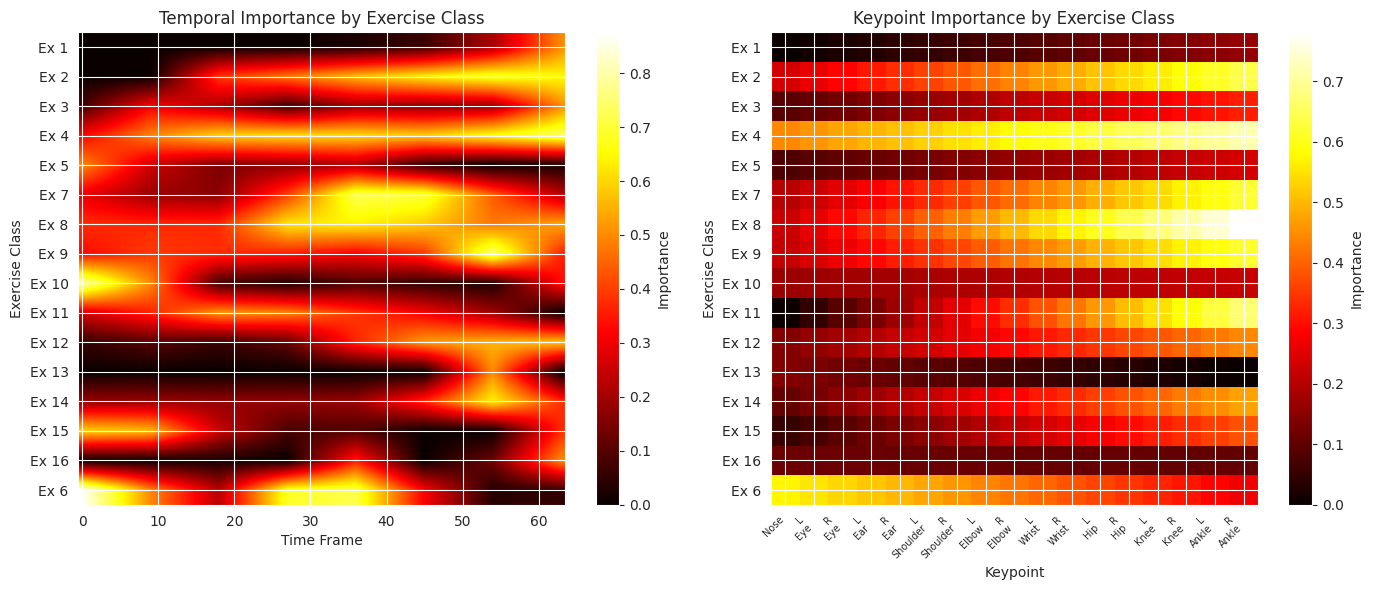

Class summary saved to: /net/afscra/people/plgmateuszoracz/wk/project/output/gradcam_class_summary.png


In [34]:
# Generate summary heatmap of average importance per class
print("\nGenerating average class importance heatmaps...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average temporal importance per class
temporal_importance_per_class = []
for result in gradcam_results:
    temporal_importance_per_class.append(result['cam'].mean(axis=1))

temporal_arr = np.array(temporal_importance_per_class)
im1 = axes[0].imshow(temporal_arr, aspect='auto', cmap='hot', interpolation='bilinear')
axes[0].set_xlabel('Time Frame')
axes[0].set_ylabel('Exercise Class')
axes[0].set_yticks(range(len(gradcam_results)))
axes[0].set_yticklabels([f"Ex {idx_to_label[r['true_class']]}" for r in gradcam_results])
axes[0].set_title('Temporal Importance by Exercise Class')
plt.colorbar(im1, ax=axes[0], label='Importance')

# Average keypoint importance per class
keypoint_names = ['Nose', 'L_Eye', 'R_Eye', 'L_Ear', 'R_Ear',
                  'L_Shoulder', 'R_Shoulder', 'L_Elbow', 'R_Elbow',
                  'L_Wrist', 'R_Wrist', 'L_Hip', 'R_Hip',
                  'L_Knee', 'R_Knee', 'L_Ankle', 'R_Ankle']

keypoint_importance_per_class = []
for result in gradcam_results:
    keypoint_importance_per_class.append(result['cam'].mean(axis=0))

keypoint_arr = np.array(keypoint_importance_per_class)
im2 = axes[1].imshow(keypoint_arr, aspect='auto', cmap='hot', interpolation='nearest')
axes[1].set_xlabel('Keypoint')
axes[1].set_ylabel('Exercise Class')
axes[1].set_xticks(range(len(keypoint_names)))
axes[1].set_xticklabels([kp.replace('_', '\n') for kp in keypoint_names], fontsize=7, rotation=45, ha='right')
axes[1].set_yticks(range(len(gradcam_results)))
axes[1].set_yticklabels([f"Ex {idx_to_label[r['true_class']]}" for r in gradcam_results])
axes[1].set_title('Keypoint Importance by Exercise Class')
plt.colorbar(im2, ax=axes[1], label='Importance')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_class_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class summary saved to: {OUTPUT_DIR / 'gradcam_class_summary.png'}")

In [35]:
# Cleanup
gradcam.remove_hooks()
print("\nGrad-CAM visualization complete!")



Grad-CAM visualization complete!
